# 🏛️ 4-Method Perturbed Benchmark — 최종 실행 노트북 v1.0

## 핵심 설계
- **Baseline 1**: Plain Text Vector RAG (perturbed 자연어 질문)
- **Baseline 2**: Text-to-Pandas JSON Plan Agent (perturbed 자연어 질문, 신규)
- **Upper Bound 1**: RDF Template SPARQL v3 (query_logic)
- **Upper Bound 2**: XLSX Template Executor v4 (query_logic)

## 실행 순서
Cell 0 → Cell 18까지 순서대로. 중간에 멈추지 말 것.

## 필요 파일 (Cell 4 업로드)
1. `budget_533.xlsx` — 원천 데이터
2. `query_logic_fullset.csv` — 골든셋 100문항
3. `budget_graph_v2.ttl` — RDF graph (선택, 없어도 RDF는 빈 결과로 처리)

## 주요 개선사항 (이전 버전 대비)
- DROP_TOKENS에서 `"원"` 제거 (false positive 매칭 방지)
- True paired bootstrap (같은 idx로 a, b 동시 resampling)
- NaN mask 처리
- ALIASES 16개 → 24개 기관으로 확장
- semantic_flags() 품질 검사 (숫자·용어·개체명 누락 검출)

In [135]:
# ============================================================
# Cell 0. 경로 설정
# ============================================================

from pathlib import Path
import os, re, json, time, zipfile, shutil, unicodedata, warnings, math
from datetime import datetime
from collections import Counter

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

ROOT       = Path("/content/2026_AI_Budget_Projects")
DATA_DIR   = ROOT / "data"
GOLD_DIR   = DATA_DIR / "goldset"
PRED_DIR   = DATA_DIR / "predictions"
RDF_DIR    = DATA_DIR / "rdf"
RESULT_DIR = ROOT / "results" / "final"
BOOT_DIR   = ROOT / "results" / "bootstrap"
FIG_DIR    = ROOT / "figures"
LOG_DIR    = ROOT / "logs"

for d in [DATA_DIR, GOLD_DIR, PRED_DIR, RDF_DIR, RESULT_DIR, BOOT_DIR, FIG_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# 입력 파일 (Cell 4에서 업로드)
QUERY_LOGIC_PATH = GOLD_DIR / "query_logic_fullset.csv"
XLSX_PATH        = DATA_DIR / "budget_533.xlsx"
TTL_PATH         = RDF_DIR / "budget_graph_v2.ttl"
PARSED_JSON_PATH = DATA_DIR / "예산현황_파싱_전체533건_교정.json"  # 5-method용 (3단계 JSON)

# 출력 파일 (perturbed v1)
PERTURBED_GOLD_PATH = GOLD_DIR / "query_logic_fullset_perturbed_v1.csv"
PERTURB_CHECK_PATH  = GOLD_DIR / "perturbation_quality_check_v1.csv"
VECTOR_PRED_PATH    = PRED_DIR / "vector_predictions_perturbed_v1.csv"
T2P_PRED_PATH       = PRED_DIR / "text_to_pandas_predictions_perturbed_v1.csv"
RDF_PRED_PATH       = PRED_DIR / "rdf_predictions_perturbed_v1.csv"
XLSX_PRED_PATH      = PRED_DIR / "xlsx_predictions_perturbed_v1.csv"
JSON_RAG_PRED_PATH  = PRED_DIR / "json_rag_predictions_perturbed_v1.csv"  # 신규 (3단계)
COMPARISON_4M_PATH  = PRED_DIR / "final_comparison_5methods_perturbed_v1.csv"
EVAL_LONG_4M_PATH   = RESULT_DIR / "final_eval_long_5methods_perturbed_v1.csv"
OVERALL_4M_PATH     = RESULT_DIR / "overall_summary_5methods_perturbed_v1.csv"
TYPE_4M_PATH        = RESULT_DIR / "type_summary_5methods_perturbed_v1.csv"
BOOT_4M_PATH        = BOOT_DIR / "paired_bootstrap_5methods_perturbed_v1_percent.csv"
BOOT_TYPE_4M_PATH   = BOOT_DIR / "paired_bootstrap_by_type_5methods_perturbed_v1_percent.csv"

print("✅ Configuration loaded")
print(f"ROOT = {ROOT}")

✅ Configuration loaded
ROOT = /content/2026_AI_Budget_Projects


In [2]:
# ============================================================
# Cell 1. 패키지 설치 (최초 1회)
# ============================================================

!pip install -q pandas numpy openpyxl rdflib tqdm openai chromadb sentence-transformers tabulate

print("✅ 패키지 설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 39.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 15.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 68.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.1/72.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.2/180.2 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.6/231.6 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 2.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not current

In [18]:
# ============================================================
# Cell 2. OpenAI 설정
# ============================================================

from openai import OpenAI
import time
import os

# 방법 1: Colab Secrets 사용 (권장)
from google.colab import userdata
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

# 방법 2: 직접 입력
# os.environ["OPENAI_API_KEY"] = "sk-..."

# 타임아웃 설정 추가
client = OpenAI(api_key=os.environ.get("OPENAI_API_KEY"), timeout=30.0)

LLM_MODEL     = "gpt-4o"           # Vector RAG, Text-to-Pandas, Perturbed 생성
EMBED_MODEL   = "jhgan/ko-sroberta-multitask"   # Vector RAG 임베딩
PERTURB_MODEL = "gpt-4o"           # Perturbed question 생성

# 재시도 로직(Retry) 추가
def call_llm(prompt: str, model: str = LLM_MODEL,
             temperature: float = 0.0, max_tokens: int = 600,
             seed: int = 42, max_retries: int = 3) -> str:
    for attempt in range(max_retries):
        try:
            resp = client.chat.completions.create(
                model=model,
                messages=[{"role": "user", "content": prompt}],
                temperature=temperature,
                seed=seed,
                max_tokens=max_tokens,
            )
            return resp.choices[0].message.content.strip()
        except Exception as e:
            if attempt < max_retries - 1:
                print(f"  [API Retry] 오류 발생: {e}. {2**attempt}초 후 재시도...")
                time.sleep(2**attempt)
            else:
                raise e

print(f"✅ OpenAI 설정 완료 | LLM: {LLM_MODEL} (Retry 적용)")

import os, getpass
from openai import OpenAI

api_key = getpass.getpass("OpenAI API Key: ").strip()  # ← .strip() 추가
os.environ["OPENAI_API_KEY"] = api_key
client = OpenAI(api_key=api_key)
print("✅ OpenAI 클라이언트 준비 완료")

✅ OpenAI 설정 완료 | LLM: gpt-4o (Retry 적용)
OpenAI API Key: ··········
✅ OpenAI 클라이언트 준비 완료


In [27]:
# ============================================================
# Cell 3. 파일 자동 탐색 + 업로드 fallback
# ============================================================

from google.colab import files
import unicodedata

def first_existing(paths):
    for p in paths:
        if Path(p).exists():
            return Path(p)
    return None

def find_json_fuzzy():
    # NFC/NFD 유니코드 인코딩 문제 해결을 위해 glob 탐색
    search_dirs = [Path("/content"), DATA_DIR, Path("/content/data")]
    for d in search_dirs:
        if not d.exists(): continue
        for f in d.glob("*.json"):
            norm_name = unicodedata.normalize('NFC', f.name)
            if "예산현황_파싱" in norm_name:
                return f
    return None

# 1단계: 자동 탐색 (이미 업로드되어 있으면 바로 사용)
auto_xlsx = first_existing([
    XLSX_PATH,
    Path("/content/budget_533.xlsx"),
    Path("/content/data/budget_533.xlsx"),
    Path("/mnt/data/budget_533.xlsx"),
])
auto_gold = first_existing([
    QUERY_LOGIC_PATH,
    Path("/content/query_logic_fullset.csv"),
    Path("/content/structured_qa_100_final_clean_querylogic_filled.csv"),
    Path("/mnt/data/query_logic_fullset.csv"),
])
auto_ttl = first_existing([
    TTL_PATH,
    Path("/content/budget_graph_v2.ttl"),
    Path("/content/data/budget_graph_v2.ttl"),
    Path("/mnt/data/budget_graph_v2.ttl"),
])
auto_json = find_json_fuzzy() or first_existing([
    PARSED_JSON_PATH,
    Path("/content/예산현황_파싱_전체533건_교정.json"),
    Path("/content/data/예산현황_파싱_전체533건_교정.json"),
    Path("/mnt/data/예산현황_파싱_전체533건_교정.json"),
])

# 자동 발견된 파일은 표준 위치로 복사
if auto_xlsx and auto_xlsx != XLSX_PATH:
    shutil.copy2(auto_xlsx, XLSX_PATH); print(f"  ✅ 복사: {auto_xlsx} → {XLSX_PATH}")
if auto_gold and auto_gold != QUERY_LOGIC_PATH:
    shutil.copy2(auto_gold, QUERY_LOGIC_PATH); print(f"  ✅ 복사: {auto_gold} → {QUERY_LOGIC_PATH}")
if auto_ttl and auto_ttl != TTL_PATH:
    shutil.copy2(auto_ttl, TTL_PATH); print(f"  ✅ 복사: {auto_ttl} → {TTL_PATH}")
if auto_json and auto_json != PARSED_JSON_PATH:
    shutil.copy2(auto_json, PARSED_JSON_PATH); print(f"  ✅ 복사: {auto_json} → {PARSED_JSON_PATH}")

# 2단계: 누락된 파일은 수동 업로드
missing = []
if not XLSX_PATH.exists():        missing.append("budget_533.xlsx")
if not QUERY_LOGIC_PATH.exists(): missing.append("query_logic_fullset.csv")
# TTL은 선택

if missing:
    print(f"\n다음 파일을 업로드하세요: {missing}")
    uploaded = files.upload()
    for fname, content in uploaded.items():
        if fname.endswith(".xlsx"):                 dest = XLSX_PATH
        elif "query_logic" in fname or "goldset" in fname: dest = QUERY_LOGIC_PATH
        elif fname.endswith(".ttl"):                dest = TTL_PATH
        elif fname.endswith(".json") and "예산현황_파싱" in unicodedata.normalize('NFC', fname): dest = PARSED_JSON_PATH
        else:                                       dest = DATA_DIR / fname
        with open(dest, "wb") as f:
            f.write(content)
        print(f"  ✅ {dest}")

# 검증
assert XLSX_PATH.exists(),        f"필수 누락: {XLSX_PATH}"
assert QUERY_LOGIC_PATH.exists(), f"필수 누락: {QUERY_LOGIC_PATH}"

print(f"\n✅ 파일 준비 완료")
print(f"   XLSX:   {XLSX_PATH.exists()}")
print(f"   골든셋: {QUERY_LOGIC_PATH.exists()}")
print(f"   TTL:    {TTL_PATH.exists()} (선택)")
print(f"   JSON:   {PARSED_JSON_PATH.exists()} (선택, 3단계 실험용)")

  ✅ 복사: /content/예산현황_파싱_전체533건_교정.json → /content/2026_AI_Budget_Projects/data/예산현황_파싱_전체533건_교정.json

✅ 파일 준비 완료
   XLSX:   True
   골든셋: True
   TTL:    True (선택)
   JSON:   True (선택, 3단계 실험용)


In [14]:
# ============================================================
# Cell 4. 데이터 로드 & 전처리
# ============================================================

# ── 4-1. XLSX 로드 ──────────────────────────────────────────
df_base = pd.read_excel(XLSX_PATH, sheet_name="사업_기본정보")
try:
    df_subj = pd.read_excel(XLSX_PATH, sheet_name="내역사업_소관및시행주체")
except Exception:
    df_subj = pd.DataFrame()

print(f"df_base : {df_base.shape}")
print(f"df_subj : {df_subj.shape if not df_subj.empty else 'N/A'}")

# ── 4-2. 지원형태 Boolean 처리 ─────────────────────────────
TRUE_VALS  = {"1", "1.0", "True", "true", "TRUE"}
FALSE_VALS = {"0", "0.0", "False", "false", "FALSE"}

support_cols = [c for c in df_base.columns if "지원형태" in c and c != "지원형태_목록"]
for col in support_cols:
    df_base[col] = df_base[col].apply(
        lambda x: True  if str(x).strip() in TRUE_VALS
             else False if str(x).strip() in FALSE_VALS
             else None
    )

# ── 4-3. 사업성격 Boolean 처리 ─────────────────────────────
for col in df_base.columns:
    if col in support_cols: continue
    vals = set(df_base[col].dropna().astype(str).str.strip().unique())
    if vals <= {"True", "False"}:
        df_base[col] = df_base[col].astype(str).str.strip() == "True"

# ── 4-4. 골든셋 로드 ────────────────────────────────────────
gold = pd.read_csv(QUERY_LOGIC_PATH)
assert len(gold) == 100, f"골든셋은 100문항이어야 함 (현재 {len(gold)})"
assert "query_logic" in gold.columns
assert gold["query_logic"].notna().sum() == 100, "query_logic 100/100 필수"

# acceptable_answers 없으면 gold로 fallback
if "acceptable_answers" not in gold.columns:
    gold["acceptable_answers"] = gold["gold"]

print(f"\n✅ 전처리 완료")
print(f"   df_base 컬럼: {len(df_base.columns)}개")
print(f"   골든셋 유형 분포: {gold['type'].value_counts().to_dict()}")

df_base : (533, 73)
df_subj : (693, 8)

✅ 전처리 완료
   df_base 컬럼: 73개
   골든셋 유형 분포: {'MultiHop': 30, 'Reverse': 30, 'ComplexFilter': 25, 'Aggregation': 15}


In [15]:
# ============================================================
# Cell 5. 정규화 & No-Oracle 평가 함수 v2
# - DROP_TOKENS에 "원" 미포함 (false positive 방지)
# - ALIASES 24개 기관
# - exact_value: 숫자 추출 우선, 실패 시 텍스트 비교 (GPT 개선)
# - acceptable_answers NaN 안전 처리 (GPT 개선)
# - matched_items: 원본 gold 보존 (GPT 개선)
# ============================================================

ALIASES = {
    "과학기술 정보통신부": ["과학기술정보통신부", "과학기술정보 통신부", "과기정통부", "과기부"],
    "중소벤처기업부": ["중기부"],
    "행정안전부": ["행안부"],
    "금융위원회": ["금융위"],
    "국토교통부": ["국토부"],
    "보건복지부": ["복지부"],
    "산업통상자원부": ["산업부", "산업통상부"],
    "고용노동부": ["고용부", "노동부"],
    "교육부": [],
    "농림축산식품부": ["농식품부", "농림부"],
    "문화체육관광부": ["문체부"],
    "해양수산부": ["해수부"],
    "기획재정부": ["기재부"],
    "경찰청": [], "해양경찰청": [], "농촌진흥청": [], "산림청": [],
    "한국지능정보사회진흥원": ["NIA", "지능정보사회진흥원", "한국지능정보사회진흥원(NIA)"],
    "정보통신산업진흥원": ["NIPA"],
    "정보통신기획평가원": ["IITP"],
    "한국연구재단": ["NRF"],
    "한국인터넷진흥원": ["KISA"],
    "한국산업기술기획평가원": ["KEIT", "한국산업기술 기획평가원"],
    "한국산업기술진흥원": ["KIAT"],
    "한국에너지공단": [],
    "한국보건산업진흥원": ["KHIDI"],
    "중소기업기술정보진흥원": ["TIPA"],
    "한국환경산업기술원": ["KEITI"],
    "한국산업은행": ["산업은행", "KDB"],
}

ALIAS_REVERSE = {}
for canonical, variants in ALIASES.items():
    for v in [canonical] + variants:
        ALIAS_REVERSE[re.sub(r"\s+", "", str(v)).lower()] = canonical

# "원" 제거됨! 기관명 끝의 "원"이 잘리지 않도록
DROP_TOKENS = ["백만원", "만원", "억원", "사업번호", "요구안", "본예산", "확정", "추경"]

def normalize_text_for_eval(text):
    if pd.isna(text):
        return ""
    text = unicodedata.normalize("NFKC", str(text)).strip()
    text = text.replace("ㆍ", "·")
    text = re.sub(r"\s+", "", text)
    key = text.lower()
    if key in ALIAS_REVERSE:
        text = ALIAS_REVERSE[key]
        text = re.sub(r"\s+", "", text)
    text = re.sub(r"[^가-힣a-zA-Z0-9()\-·]", "", text).lower()
    for token in DROP_TOKENS:
        text = text.replace(token, "")
    return text.strip()

def split_items(text):
    if pd.isna(text) or str(text).strip() in ["", "nan", "None",
            "(조건에 맞는 결과 없음)", "(컬럼 없음)", "(지원하지 않는 query_logic 패턴)", "(미지원 패턴)"]:
        return []
    text = str(text).strip()
    text = re.sub(r"(?m)^\s*[-*•]\s*", "", text)
    if "|" in text:
        return [p.strip() for p in text.split("|") if p.strip()]
    if "\n" in text:
        return [p.strip() for p in text.split("\n") if p.strip()]
    return [p.strip() for p in re.split(r"\s*/\s*|\s*,\s*|\s*;\s*", text) if p.strip()]

def extract_number(text):
    """GPT 개선: 텍스트에서 숫자만 추출 (콤마/공백 무시)"""
    if pd.isna(text): return None
    s = str(text).replace(",", "").replace(" ", "")
    m = re.search(r"-?\d+(?:\.\d+)?", s)
    if m:
        try: return float(m.group())
        except: return None
    return None

def pick_answer(row):
    """GPT 개선: NaN 안전 처리"""
    for col in ["acceptable_answers", "gold", "answer", "정답"]:
        if col in row.index:
            val = row.get(col)
            if pd.notna(val) and str(val).strip() not in ["", "nan", "None"]:
                return val
    return ""

def score_prediction(pred, acceptable, mode="any_3_from_candidate_set", answer_limit=3):
    pred_items_raw = split_items(pred)
    gold_items_raw = split_items(acceptable)

    pred_items_norm = [normalize_text_for_eval(x) for x in pred_items_raw if normalize_text_for_eval(x)]
    gold_items_norm = [normalize_text_for_eval(x) for x in gold_items_raw if normalize_text_for_eval(x)]

    if not gold_items_norm:
        return 0.0, 0.0, 0.0, []

    mode = str(mode or "any_3_from_candidate_set")
    try: limit = max(1, int(answer_limit))
    except: limit = 3

    # ── exact_value: 숫자 추출 우선 (GPT 개선), 실패 시 텍스트 ──
    if mode == "exact_value":
        pn = extract_number(pred)
        an = extract_number(acceptable)
        if pn is not None and an is not None:
            if abs(pn - an) < 1e-6:
                return 1.0, 1.0, 1.0, [str(acceptable)]
            return 0.0, 0.0, 0.0, []
        # 숫자 추출 실패 → 텍스트 정규화 비교 fallback
        pred_norm = normalize_text_for_eval(pred)
        gold_norm = normalize_text_for_eval(acceptable)
        if pred_norm == gold_norm and pred_norm != "":
            return 1.0, 1.0, 1.0, [str(acceptable)]
        return 0.0, 0.0, 0.0, []

    # ── set 기반 매칭 (substring 매칭 의도적으로 배제: false positive 방지) ──
    pred_set = set(pred_items_norm)
    gold_set = set(gold_items_norm)
    matched_norm = pred_set & gold_set

    # GPT 개선: matched_items에 원본 gold 문자열 보존
    matched_original = []
    for raw in gold_items_raw:
        if normalize_text_for_eval(raw) in matched_norm:
            matched_original.append(raw)

    if mode == "exact_set":
        if not pred_set and not gold_set:
            return 1.0, 1.0, 1.0, []
        p = len(matched_norm)/len(pred_set) if pred_set else 0.0
        r = len(matched_norm)/len(gold_set) if gold_set else 0.0
        f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
        return p, r, f1, matched_original

    # any_3_from_candidate_set
    p = len(matched_norm)/len(pred_set) if pred_set else 0.0
    r = len(matched_norm)/min(len(gold_set), limit) if gold_set else 0.0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    return p, r, f1, matched_original

def evaluate_method(gold_df, comparison_df, pred_col, method_name):
    tmp = comparison_df[["id", pred_col]].copy().rename(columns={pred_col: "pred"})
    merged = tmp.merge(
        gold_df[["id", "type", "question", "gold", "acceptable_answers", "answer_limit", "evaluation_mode"]],
        on="id", how="left"
    )
    rows = []
    for _, row in merged.iterrows():
        limit = int(row.get("answer_limit", 3) or 3)
        mode = str(row.get("evaluation_mode", "any_3_from_candidate_set") or "any_3_from_candidate_set")
        acceptable = pick_answer(row)
        p, r, f1, matched = score_prediction(
            str(row.get("pred", "")), str(acceptable),
            mode=mode, answer_limit=limit
        )
        rows.append({
            "id": row["id"], "type": row["type"], "question": row["question"],
            "method": method_name, "pred": row.get("pred", ""),
            "precision": p, "recall": r, "f1": f1,
            "matched_items": " | ".join(matched),
        })
    return pd.DataFrame(rows)

print("✅ 평가 함수 v2 준비 완료")
print(f"   ALIASES: {len(ALIASES)}개 기관")
print(f"   DROP_TOKENS: {DROP_TOKENS}")
print(f"   exact_value: 숫자 추출 우선 (GPT 개선)")
print(f"   item matching: set 기반 (substring 배제 — false positive 방지)")

✅ 평가 함수 v2 준비 완료
   ALIASES: 29개 기관
   DROP_TOKENS: ['백만원', '만원', '억원', '사업번호', '요구안', '본예산', '확정', '추경']
   exact_value: 숫자 추출 우선 (GPT 개선)
   item matching: set 기반 (substring 배제 — false positive 방지)


In [16]:
# ============================================================
# Cell 6. 질의 패턴 Taxonomy 할당 (전략 B)
# ============================================================

QUESTION_PATTERNS = {
    "ministry_total_budget":   "예산 심의에서 부처별 총액·증감·신규사업 규모 확인",
    "agency_project_count":    "산하기관·전문기관별 사업 집중도 및 역할 확인",
    "support_type_filter":     "재정지원 방식별 적정성·보조사업 관리 대상 확인",
    "new_continuing_project":  "신규 사업 편성 타당성·계속사업 구조조정 검토",
    "large_budget_filter":     "대규모 재정투입 사업의 우선순위·타당성 확인",
    "agency_ministry_relation": "위탁·수행기관과 소관부처 간 역할 관계 확인",
    "field_sector_reverse":    "정책 분야별 예산 분포·사업 구성 확인",
}

def assign_pattern(row):
    q, t = str(row.get("question", "")), str(row.get("type", ""))
    if ("합계" in q or "총액" in q) and t == "Aggregation": return "ministry_total_budget"
    if "몇 개" in q: return "agency_project_count"
    if any(x in q for x in ["출연", "보조", "출자", "융자", "지원형태"]): return "support_type_filter"
    if any(x in q for x in ["신규", "계속"]): return "new_continuing_project"
    if any(x in q for x in ["이상", "가장 큰"]): return "large_budget_filter"
    if "시행기관" in q and any(x in q for x in ["소관", "부문", "단위사업"]): return "agency_ministry_relation"
    if any(x in q for x in ["분야", "부문"]): return "field_sector_reverse"
    return {"Aggregation": "ministry_total_budget", "ComplexFilter": "support_type_filter",
            "MultiHop": "agency_ministry_relation", "Reverse": "field_sector_reverse"}.get(t, "ministry_total_budget")

gold["question_pattern"] = gold.apply(assign_pattern, axis=1)
gold["pattern_motif"] = gold["question_pattern"].map(QUESTION_PATTERNS)

print("✅ Taxonomy 할당 완료")
print(gold["question_pattern"].value_counts())

✅ Taxonomy 할당 완료
question_pattern
support_type_filter         40
agency_ministry_relation    24
new_continuing_project      17
agency_project_count         9
field_sector_reverse         6
ministry_total_budget        4
Name: count, dtype: int64


In [19]:
# ============================================================
# Cell 7. Perturbed 질문 생성 (전략 C, 30/50/20 분포)
# ============================================================

REGENERATE_PERTURBED = False  # 한 번 생성 후 고정 (재실행 시 같은 파일 재사용)
# 처음 실행이거나 재생성하고 싶으면 True로 변경

NOISE_LEVELS = {
    "L1_strict":    "원래 질문 의미를 유지하되 표현만 자연스럽게 바꾼다.",
    "L2_realistic": "약어, 동의어, 구어체를 일부 포함한다.",
    "L3_perturbed": "조건 일부를 암묵화하거나 행정 실무 표현을 사용한다.",
}

def assign_noise_level(i):
    if i < 30: return "L1_strict"
    if i < 80: return "L2_realistic"
    return "L3_perturbed"

ALIAS_HINTS = """
약어/동의어 예시:
- 과학기술정보통신부 → 과기정통부, 과기부
- 금융위원회 → 금융위 | 중소벤처기업부 → 중기부
- 산업통상자원부 → 산업부 | 국토교통부 → 국토부
- 보건복지부 → 복지부 | 고용노동부 → 고용부
- 농림축산식품부 → 농식품부 | 해양수산부 → 해수부
- 한국지능정보사회진흥원 → NIA | 정보통신산업진흥원 → NIPA
- 정보통신기획평가원 → IITP | 한국연구재단 → NRF
- 한국인터넷진흥원 → KISA
- 신규 사업 → 새로 시작하는 사업, 내년에 새로 하는 사업
- 예산 합계 → 다 합치면 얼마, 총액
- 지원형태가 보조 → 보조사업, 국고보조 형태
"""

def generate_perturbed_question(row):
    prompt = f"""너는 공공 예산 데이터 질의 벤치마크를 만드는 연구 보조자다.
원래 질문을 실제 사용자가 묻는 자연어로 바꿔라.

[절대 규칙]
1. 정답 기준을 바꾸지 마라.
2. query_logic의 조건과 연산은 그대로 유지되어야 한다.
3. 새로운 조건을 추가/삭제하지 마라.
4. 숫자, 기관명, 지원형태, 사업성격 의미를 바꾸지 마라.
5. 변형된 질문 한 문장만 출력하라. 설명·따옴표·번호 없이.

질문 유형: {row['type']} | 패턴: {row['question_pattern']}
변형 난이도: {row['question_noise_level']} — {NOISE_LEVELS[row['question_noise_level']]}

{ALIAS_HINTS}

원래 질문: {row['question_original']}
query_logic: {row['query_logic']}

변형 질문:"""
    return call_llm(prompt, model=PERTURB_MODEL, temperature=0.2,
                    max_tokens=300, seed=100 + int(row.name))

def infer_noise_type(orig, pert):
    tags = []
    if any(x in str(pert) for x in ["NIA","NIPA","IITP","NRF","KISA","KDB","KEIT","KIAT","KHIDI","TIPA","KEITI",
                                      "과기부","과기정통부","금융위","국토부","복지부","산업부","중기부","고용부","해수부","문체부","농식품부"]):
        tags.append("abbreviation")
    if any(x in str(pert) for x in ["얼마","뭐야","좀","다 합치면","찾아줘","뽑아","인가요","주세요","어떤"]):
        tags.append("colloquial")
    if len(str(pert)) < len(str(orig)) * 0.75:
        tags.append("ellipsis")
    if not tags: tags.append("surface_rewrite")
    return "|".join(tags)

if PERTURBED_GOLD_PATH.exists() and not REGENERATE_PERTURBED:
    gold_pert = pd.read_csv(PERTURBED_GOLD_PATH)
    print(f"✅ 기존 파일 로드: {PERTURBED_GOLD_PATH}")
else:
    gold_pert = gold.copy().reset_index(drop=True)
    gold_pert["question_original"] = gold_pert["question"]
    gold_pert["question_noise_level"] = [assign_noise_level(i) for i in range(len(gold_pert))]

    qs = []
    for i, row in gold_pert.iterrows():
        try:
            q_new = generate_perturbed_question(row)
        except Exception as e:
            print(f"  ERROR [{i}] {row['id']}: {e}")
            q_new = row["question_original"]
        qs.append(q_new)
        print(f"[{i:03d}] {row['id']} {row['question_noise_level']} → {q_new[:70]}")
        time.sleep(0.2)

    gold_pert["question_perturbed"] = qs
    gold_pert["noise_type"] = [infer_noise_type(o, p) for o, p in zip(gold_pert["question_original"], gold_pert["question_perturbed"])]
    gold_pert["question"] = gold_pert["question_perturbed"]
    gold_pert.to_csv(PERTURBED_GOLD_PATH, index=False, encoding="utf-8-sig")
    print(f"\n✅ 저장: {PERTURBED_GOLD_PATH}")

display(gold_pert[["id","type","question_original","question_perturbed","question_noise_level","noise_type"]].head(10))

[000] MH01 L1_strict → NIPA가 시행기관인 사업들의 소관기관을 최대 3개까지 알려줘.
[001] MH02 L1_strict → NIA가 시행기관으로 있는 사업들이 포함된 단위사업명을 최대 3개까지 알려줘.
[002] MH03 L1_strict → 한국산업은행이 시행하는 사업들의 소관기관과 지원형태를 각각 알려줘.
[003] MH04 L1_strict → 한국에너지공단이 진행하는 사업들은 어떤 분야에 속하나요?
[004] MH05 L1_strict → 2026년에 정보통신기획평가원이 시행하는 사업들의 예산 총액은 얼마인가요?
[005] MH06 L1_strict → 중소기업기술정보진흥원이 진행하는 내역사업들은 어떤 기관의 소관인가요?
[006] MH07 L1_strict → 해양경찰청에서 관할하는 사업을 시행하는 기관은 어디인가요?
[007] MH08 L1_strict → AI컴퓨팅자원활용기반강화 사업을 수행하는 기관들이 맡고 있는 다른 사업 이름을 최대 3개까지 알려주세요.
[008] RV01 L1_strict → NIA가 시행하는 사업의 개수는 몇 개야?
[009] RV02 L1_strict → 정보통신산업진흥원이 시행하는 사업 중 3개만 이름을 알려줄래?
[010] RV03 L1_strict → 고용부 소관의 출연 형태로 지원되는 사업 중에서 3개를 알려주세요.
[011] RV04 L1_strict → 2026년에 새로 시작하는 사업 중에서 지원 형태가 출자인 사업을 최대 3개까지 알려줘.
[012] RV05 L1_strict → 금융위에서 새로 시작하는 사업 중 3개만 알려줄 수 있나요?
[013] RV06 L1_strict → 3년 동안 진행되는 새로 시작하는 사업 중 3개를 알려주세요.
[014] CF01 L1_strict → 과기정통부 소관 사업 중에서 출연 형태로 지원받고 2026년 예산이 1000억 원 이상인 사업을 최대 3개까지 알려줘.
[015] CF02 L1_strict → 과기정통부 소관의 새로 시작하는 사업 중에서 지

,id,type,question_original,question_perturbed,question_noise_level,noise_type
0,MH01,MultiHop,정보통신산업진흥원이 시행기관인 사업들의 소관기관 3개까지 나열하시오.,NIPA가 시행기관인 사업들의 소관기관을 최대 3개까지 알려줘.,L1_strict,abbreviation
1,MH02,MultiHop,한국지능정보사회진흥원이 시행기관인 사업들이 속한 단위사업명 3개까지 나열하시오.,NIA가 시행기관으로 있는 사업들이 포함된 단위사업명을 최대 3개까지 알려줘.,L1_strict,abbreviation
2,MH03,MultiHop,한국산업은행이 시행기관인 사업들의 소관기관과 지원형태를 나열하시오.,한국산업은행이 시행하는 사업들의 소관기관과 지원형태를 각각 알려줘.,L1_strict,surface_rewrite
3,MH04,MultiHop,한국에너지공단이 시행하는 사업의 분야명은?,한국에너지공단이 진행하는 사업들은 어떤 분야에 속하나요?,L1_strict,colloquial
4,MH05,MultiHop,정보통신기획평가원이 시행기관인 사업들의 2026년 예산 합계는?,2026년에 정보통신기획평가원이 시행하는 사업들의 예산 총액은 얼마인가요?,L1_strict,colloquial
5,MH06,MultiHop,중소기업기술정보진흥원이 시행하는 내역사업들의 소관기관은?,중소기업기술정보진흥원이 진행하는 내역사업들은 어떤 기관의 소관인가요?,L1_strict,colloquial
6,MH07,MultiHop,해양경찰청 소관 사업의 시행기관은?,해양경찰청에서 관할하는 사업을 시행하는 기관은 어디인가요?,L1_strict,colloquial
7,MH08,MultiHop,AI컴퓨팅자원활용기반강화 사업의 내역사업 시행기관들이 담당하는 다른 사업명은 3개까...,AI컴퓨팅자원활용기반강화 사업을 수행하는 기관들이 맡고 있는 다른 사업 이름을 최대...,L1_strict,colloquial
8,RV01,Reverse,한국지능정보사회진흥원이 시행기관인 사업은 몇 개인가?,NIA가 시행하는 사업의 개수는 몇 개야?,L1_strict,abbreviation
9,RV02,Reverse,정보통신산업진흥원이 시행기관인 사업명을 3개 나열하시오.,정보통신산업진흥원이 시행하는 사업 중 3개만 이름을 알려줄래?,L1_strict,surface_rewrite


In [20]:
# ============================================================
# Cell 8. Perturbed 질문 품질 검사 (semantic_flags)
# ============================================================

def extract_numbers(s):
    return set(re.findall(r"\d+", str(s)))

def semantic_flags(row):
    orig  = str(row.get("question_original", ""))
    pert  = str(row.get("question_perturbed", ""))
    logic = str(row.get("query_logic", ""))
    flags = []

    # 숫자 누락
    missing_nums = extract_numbers(orig) - extract_numbers(pert) - extract_numbers(logic)
    if missing_nums:
        flags.append("number_missing:" + ",".join(sorted(missing_nums)))

    # 핵심 용어 누락
    for term in ["신규", "계속", "출연", "보조", "출자", "융자", "일반회계", "기금"]:
        if term in orig and term not in pert and term not in logic:
            flags.append("term_missing:" + term)

    # query_logic 개체명 누락
    quoted = re.findall(r"['\"]([^'\"]+)['\"]", logic)
    for ent in quoted:
        ent_compact = re.sub(r"\s+", "", ent)
        pert_compact = re.sub(r"\s+", "", pert)
        if len(ent_compact) >= 3 and ent_compact not in pert_compact:
            alias_ok = False
            for canonical, vars_ in ALIASES.items():
                if ent == canonical or ent in vars_:
                    alias_ok = any(re.sub(r"\s+", "", v) in pert_compact
                                    for v in [canonical] + vars_)
                    if alias_ok: break
            if not alias_ok:
                flags.append("entity_missing:" + ent)
    return "|".join(flags)

check_df = gold_pert[["id","type","question_original","question_perturbed",
                       "query_logic","question_noise_level","noise_type"]].copy()
check_df["orig_len"] = check_df["question_original"].astype(str).str.len()
check_df["pert_len"] = check_df["question_perturbed"].astype(str).str.len()
check_df["len_ratio"] = check_df["pert_len"] / check_df["orig_len"].replace(0, np.nan)
check_df["semantic_flags"] = gold_pert.apply(semantic_flags, axis=1)
check_df["needs_review"] = (
    (check_df["len_ratio"] < 0.4) |
    (check_df["len_ratio"] > 2.0) |
    (check_df["question_perturbed"].astype(str).str.len() < 8) |
    (check_df["semantic_flags"].astype(str).str.len() > 0)
)
check_df.to_csv(PERTURB_CHECK_PATH, index=False, encoding="utf-8-sig")

print(f"총 {len(check_df)}문항 / 검토 필요 {int(check_df['needs_review'].sum())}건")
if check_df["needs_review"].sum() > 0:
    print("\n⚠️ 검토 필요 항목 (수동 검토 후 query_logic_fullset_perturbed_v1.csv 직접 수정 가능):")
    display(check_df[check_df["needs_review"]].head(20))

총 100문항 / 검토 필요 1건

⚠️ 검토 필요 항목 (수동 검토 후 query_logic_fullset_perturbed_v1.csv 직접 수정 가능):


,id,type,question_original,question_perturbed,query_logic,question_noise_level,noise_type,orig_len,pert_len,len_ratio,semantic_flags,needs_review
98,SQA079,Aggregation,산업통상부 소관 사업 중 2026년 예산이 전년 대비 감소한 사업은 몇 개인가?,산업부에서 내년에 예산이 줄어드는 사업은 몇 개야?,소관={'산업통상부'} AND 예산총괄표_증감(백만원)<0 -> unique 사업명...,L3_perturbed,abbreviation|ellipsis,44,28,0.636364,number_missing:2026,True


In [28]:
# ============================================================
# Cell 9. Vector RAG 구축 (ChromaDB + 임베딩)
# ============================================================

import chromadb
from sentence_transformers import SentenceTransformer

print("임베딩 모델 로드...")
embed_model = SentenceTransformer(EMBED_MODEL)

chroma_client = chromadb.Client()
try: chroma_client.delete_collection("budget")
except: pass
collection = chroma_client.create_collection("budget")

def row_to_text(row):
    def v(c):
        val = row.get(c, "")
        return "" if pd.isna(val) else str(val)
    return "\n".join([
        f"[사업번호] {v('사업번호')}",
        f"[사업명] {v('사업명')}",
        f"[소관] {v('소관')}",
        f"[분야명] {v('분야명')} / 부문: {v('부문명')}",
        f"[프로그램] {v('프로그램명')} > {v('단위사업명')} > {v('세부사업명')}",
        f"[지원형태] {v('지원형태_목록')}",
        f"[시행기관] {v('사업시행주체_목록')}",
        f"[신규여부] {'신규' if str(v('사업성격_신규'))=='True' else '계속'}",
        f"[2026예산(백만원)] {v('사업규모_2026(백만원)')}",
        f"[사업기간] {v('사업기간')}",
    ])

docs = [row_to_text(r) for _, r in df_base.iterrows()]
ids  = [f"p{i:04d}" for i in range(len(docs))]

# 배치 임베딩
BATCH = 64
all_embs = []
for i in range(0, len(docs), BATCH):
    batch = docs[i:i+BATCH]
    embs = embed_model.encode(batch, show_progress_bar=False).tolist()
    all_embs.extend(embs)

collection.add(documents=docs, embeddings=all_embs, ids=ids)
print(f"✅ ChromaDB 구축 완료 — {len(docs)}개 청크")

임베딩 모델 로드...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: jhgan/ko-sroberta-multitask
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ ChromaDB 구축 완료 — 533개 청크


In [29]:
# ============================================================
# Cell 9b. JSON Vector RAG 구축 (3단계 - 신규 Method)
# 옵션 나-1: 핵심 필드만 추출 (사업목적 제외) — Plain Text와 공정 비교
# ============================================================

if not PARSED_JSON_PATH.exists():
    print("⚠️ 예산현황_파싱_전체533건_교정.json 없음 — JSON RAG 생략")
    json_collection = None
else:
    with open(PARSED_JSON_PATH, encoding="utf-8") as f:
        parsed_json = json.load(f)
    print(f"✅ JSON 파일 로드: {len(parsed_json)}건")

    def json_chunk_essential(item):
        """핵심 필드만 JSON 형식으로 추출 (옵션 나-1)"""
        sgk = item.get("사업코드", {}) or {}
        담당 = item.get("사업담당자", []) or []
        시행기관 = list({d.get("사업시행주체","") for d in 담당 if d.get("사업시행주체")})
        예산총괄 = item.get("예산총괄", {}) or {}
        # 2026확정 우선, 없으면 사업규모_연도별의 2026
        budget_2026 = 예산총괄.get("2026확정(B)") or item.get("사업규모_연도별사업비(백만원)",{}).get("2026","")
        try: budget_2026 = int(str(budget_2026).replace(",",""))
        except: budget_2026 = None
        chunk = {
            "사업명": item.get("사업명",""),
            "소관": sgk.get("소관_명칭",""),
            "분야": {"코드": sgk.get("분야_코드",""), "명칭": sgk.get("분야_명칭","")},
            "부문": {"코드": sgk.get("부문_코드",""), "명칭": sgk.get("부문_명칭","")},
            "프로그램": sgk.get("프로그램_명칭",""),
            "단위사업": sgk.get("단위사업_명칭",""),
            "세부사업": sgk.get("세부사업_명칭",""),
            "지원형태": item.get("지원형태", []),
            "사업성격": item.get("사업성격", []),
            "시행기관": 시행기관,
            "예산_2026": budget_2026,
        }
        return json.dumps(chunk, ensure_ascii=False)

    json_docs = [json_chunk_essential(item) for item in parsed_json]
    json_ids  = [f"j{i:04d}" for i in range(len(json_docs))]
    print(f"JSON 청크 생성: {len(json_docs)}개")
    print(f"평균 길이: {sum(len(d) for d in json_docs)//len(json_docs)}자")
    print(f"샘플 청크 (첫 번째):\n{json_docs[0][:300]}...")

    # 별도 collection
    try: chroma_client.delete_collection("budget_json")
    except: pass
    json_collection = chroma_client.create_collection("budget_json")

    BATCH = 64
    json_embs = []
    for i in range(0, len(json_docs), BATCH):
        batch = json_docs[i:i+BATCH]
        embs = embed_model.encode(batch, show_progress_bar=False).tolist()
        json_embs.extend(embs)
    json_collection.add(documents=json_docs, embeddings=json_embs, ids=json_ids)
    print(f"✅ JSON Vector RAG 구축 완료 — {len(json_docs)}개 청크")

✅ JSON 파일 로드: 533건
JSON 청크 생성: 533개
평균 길이: 282자
샘플 청크 (첫 번째):
{"사업명": "1. 감사원_전산운영경비(정보화)", "소관": "감사원", "분야": {"코드": "010", "명칭": "일반·지방행정"}, "부문": {"코드": "016", "명칭": "일반행정"}, "프로그램": "감사활동 및 행정지원", "단위사업": "전산운영경비", "세부사업": "전산운영경비(정보화)", "지원형태": ["직접"], "사업성격": ["계속"], "시행기관": ["감사원"], "예산_2026": 10300}...
✅ JSON Vector RAG 구축 완료 — 533개 청크


In [23]:
# ============================================================
# Cell 10. Baseline 1: Plain Text Vector RAG 100문항 실행
# ============================================================

def run_vector_rag(question: str, top_k: int = 5) -> str:
    q_emb = embed_model.encode([question]).tolist()
    results = collection.query(query_embeddings=q_emb, n_results=top_k, include=["documents"])
    docs_ret = results["documents"][0]

    parts, used = [], 0
    for doc in docs_ret:
        d = doc[:3000]
        if used + len(d) > 12000: break
        parts.append(d); used += len(d)
    context = "\n\n---\n\n".join(parts)

    prompt = f"""아래 예산설명서 정보를 근거로 질문에 답하시오.
정답만 간결하게 답하시오. 목록형 답변은 ' | '로 구분하시오.
숫자 답변은 단위(백만원 또는 개)와 함께 답하시오. 근거 없으면 '알 수 없음'.

[질문] {question}

[정보]
{context}"""
    return call_llm(prompt)

vector_rows = []
for _, row in gold_pert.iterrows():
    q = row["question_perturbed"]
    try:
        pred = run_vector_rag(q)
        status = "ok"
    except Exception as e:
        pred, status = "", f"error: {e}"
    vector_rows.append({"id": row["id"], "vector_pred": pred, "vector_status": status})
    print(f"  {row['id']}: {pred[:60]}")
    time.sleep(0.2)

vector_df = pd.DataFrame(vector_rows)
vector_df.to_csv(VECTOR_PRED_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ Vector RAG 저장: {VECTOR_PRED_PATH}")

  MH01: 과학기술정보통신부
  MH02: 국가지식정보 연계 및 활용 촉진(정보화)
  MH03: 알 수 없음
  MH04: 산업·중소기업 및 에너지 / 부문: 에너지 및 자원개발
  MH05: 44426.0 백만원
  MH06: 중소벤처기업부
  MH07: 해양경찰청 | 해양수산과학기술진흥원 | 알 수 없음
  MH08: 제조업 AI융합 기반 조성 | AI·공간컴퓨팅 창업 생태계 활성화
  RV01: 1개
  RV02: 알 수 없음
  RV03: 알 수 없음
  RV04: 알 수 없음
  RV05: 산업은행 출자(국민성장펀드)
  RV06: 국가농업AX플랫폼 | 극한지스마트광역탐사를위한 로봇-ICT융합기술개발(R&D)
  CF01: 91 | 39
  CF02: 알 수 없음
  CF03: 창업사업화지원 | 중소벤처행정정보화(정보화) | ICT융합스마트공장보급·확산
  CF04: AI반도체실증지원 | 차세대 네트워크(6G) 산업 기술개발 | 디지털분야글로벌인재양성(R&D)
  CF05: 알 수 없음
  CF06: 알 수 없음
  MH09: 과학기술 정보통신부
  MH11: 산업통상부 | 과학기술정보통신부 | 알 수 없음
  MH12: 과학기술 정보통신부 | 개인정보 보호위원회 | 행정안전부
  MH13: 과학기술정보통신부
  MH14: 보건복지부
  MH15: 개인정보 보호위원회
  MH17: 산업통상부 | 한국산업기술진흥원 | 한국섬유산업연합회
  MH18: AI-RAN 글로벌 선도 프로젝트(R&D) | 데이터센터 네트워크 인프라 기술 선도사업(R&D) | 복합지능
  MH19: AI반도체실증지원
  MH20: 기계장비산업기술개발(R&D)
  MH21: 국가지식정보 연계 및 활용 촉진(정보화)
  MH22: 통신
  MH23: 통신 | 과학기술
  MH24: 산업혁신지원
  MH25: 통신
  MH26: 국방AI선도연구협력(R&D) | 차세대 네트워크 AI파운데이션 모델(NFM) 개발(R&D) | AI-RAN 
  MH27: 지역거점AX혁신기술개발 | 바이

In [31]:
# ============================================================
# Cell 10b. Baseline 3 (NEW): JSON Vector RAG 100문항 실행
# 3단계 머신리더블 (CSV/JSON/XML) 표현 검증
# ============================================================

def run_json_vector_rag(question: str, top_k: int = 5) -> str:
    if json_collection is None:
        return "(JSON 파일 없음)"
    q_emb = embed_model.encode([question]).tolist()
    results = json_collection.query(query_embeddings=q_emb, n_results=top_k, include=["documents"])
    docs_ret = results["documents"][0]

    parts, used = [], 0
    for doc in docs_ret:
        d = doc[:3000]
        if used + len(d) > 12000: break
        parts.append(d); used += len(d)
    context = "\n\n---\n\n".join(parts)

    prompt = f"""아래는 정부 예산 사업 정보를 JSON 형식으로 표현한 데이터입니다.
이 정보를 근거로 질문에 답하시오.
정답만 간결하게. 목록형 답변은 ' | '로 구분. 숫자는 단위(백만원 또는 개)와 함께. 근거 없으면 '알 수 없음'.

[질문] {question}

[예산 사업 JSON 정보]
{context}"""
    return call_llm(prompt)

json_rag_rows = []
for _, row in gold_pert.iterrows():
    q = row["question_perturbed"]
    try:
        pred = run_json_vector_rag(q)
        status = "ok"
    except Exception as e:
        pred, status = "", f"error: {e}"
    json_rag_rows.append({"id": row["id"], "json_rag_pred": pred, "json_rag_status": status})
    print(f"  {row['id']}: {pred[:300]}")
    time.sleep(0.2)

json_rag_df = pd.DataFrame(json_rag_rows)
json_rag_df.to_csv(JSON_RAG_PRED_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ JSON Vector RAG 저장: {JSON_RAG_PRED_PATH}")

  MH01: 과학기술정보통신부
  MH02: 스마트화산업기반확충(일반)
  MH03: 금융위원회 | 과학기술정보통신부 | 출자 | 출자
  MH04: 알 수 없음
  MH05: 4500백만원
  MH06: 중소벤처기업부
  MH07: 해양수산과학기술진흥원 | 해양경찰청 | 미정
  MH08: AI 공간 컴퓨팅 창업 생태계 활성화 | AI AGENT 선도 국가 사업 | 국가 AI데이터센터 고도화
  RV01: 2개
  RV02: 알 수 없음
  RV03: 21. 고용노동부_미래환경변화 대응 산업안전보건 연구개발(R&D)
  RV04: 203. 과학기술정보통신부_한국산업은행출자(AI컴퓨팅 인프라 확충)
  RV05: 금융위에서 새로 시작하는 사업: 알 수 없음
  RV06: 333. 농림축산식품부_국가 농업 AX플랫폼
  CF01: 201. 과학기술정보통신부_한국기초과학지원연구원 연구 운영비 지원(R&D) | 183. 과학기술정보통신부_차세대네트워크(6G) 산업기술개발(R&D)
  CF02: 알 수 없음
  CF03: 중소벤처기업부_투·융자연계기술개발(R&D)
  CF04: 192. 과학기술정보통신부_칩렛 기반 저전력 온디바이스 AI 반도체 기술개발(R&D)
  CF05: 431. 산업통상부_산업혁신인재성장지원(R&D) | 436. 산업통상부_열공정특화제조AI파운데이션모델개발(R&D) | 417. 산업통상부_미래이차전지원료소재실증플랫폼기반구축
  CF06: AI 기반 분산전력망 산업 육성
  MH09: 과학기술정보통신부
  MH11: 과학기술정보통신부
  MH12: 과학기술정보통신부 | 병무청 | 개인정보 보호위원회
  MH13: 알 수 없음
  MH14: 보건복지부 | 산업통상부
  MH15: 개인정보 보호위원회 | 과학기술정보통신부 | 행정안전부
  MH17: 산업통상부 | 21 산업통상부
  MH18: 콘텐츠디바이스기술개발 (일반) | 전파연구지원
  MH19: 알 수 없음
  MH20: 알 수 없음
  MH21: 스마트화산업기반확충 | SW산업경쟁력강화(

In [157]:
# # ============================================================
# # Cell 11. Baseline 2: Text-to-Pandas JSON Plan Agent 100문항 실행
# # ============================================================

# import re, json, time, unicodedata
# import pandas as pd

# def alias_key(x):
#     if pd.isna(x):
#         return ""
#     s = unicodedata.normalize("NFKC", str(x)).strip()
#     s = re.sub(r"\([^)]*\)", "", s)  # (NIA), (NIPA) 제거
#     s = s.replace("ㆍ", "·")
#     s = re.sub(r"\s+", "", s)
#     return s.lower()

# RAW_ALIASES = {
#     "과학기술 정보통신부": ["과학기술정보통신부", "과학기술정보 통신부", "과기정통부", "과기부"],
#     "한국지능정보사회진흥원": ["NIA", "nia", "지능정보사회진흥원", "한국지능정보사회진흥원(NIA)"],
#     "정보통신산업진흥원": ["NIPA", "nipa", "정보통신산업진흥원(NIPA)"],
#     "정보통신기획평가원": ["IITP", "iitp", "정보통신기획평가원(IITP)"],
#     "한국산업은행": ["산업은행", "KDB", "kdb", "한국산업은행(KDB)"],
#     "한국인터넷진흥원": ["KISA", "kisa", "한국인터넷진흥원(KISA)"],
#     "한국연구재단": ["NRF", "nrf"],
#     "중소벤처기업부": ["중기부"],
#     "행정안전부": ["행안부"],
#     "금융위원회": ["금융위"],
#     "국토교통부": ["국토부"],
#     "보건복지부": ["복지부"],
#     "산업통상자원부": ["산업부", "산업통상부", "산자부"],
#     "고용노동부": ["고용부", "노동부"],
#     "교육부": [],
#     "농림축산식품부": ["농식품부", "농림부"],
#     "문화체육관광부": ["문체부"],
#     "해양수산부": ["해수부"],
#     "경찰청": [],
#     "해양경찰청": ["해경청"],
#     "농촌진흥청": ["농진청"],
#     "한국산업기술기획평가원": ["KEIT", "keit", "한국산업기술 기획평가원"],
#     "한국산업기술진흥원": ["KIAT", "kiat"],
#     "한국에너지공단": ["에너지공단"],
#     "한국보건산업진흥원": ["KHIDI", "khidi"],
#     "중소기업기술정보진흥원": ["TIPA", "tipa"],
#     "한국환경산업기술원": ["KEITI", "keiti"],
#     "기획재정부": ["기재부"],
# }

# EXEC_ALIASES = {}

# for canonical, variants in RAW_ALIASES.items():
#     # canonical 자기 자신도 등록
#     EXEC_ALIASES[alias_key(canonical)] = canonical

#     # variants도 canonical로 등록
#     for variant in variants:
#         EXEC_ALIASES[alias_key(variant)] = canonical

# def expand_alias_exec(x):
#     raw = "" if pd.isna(x) else str(x).strip()
#     return EXEC_ALIASES.get(alias_key(raw), raw)

# def split_multi(x):
#     if pd.isna(x):
#         return []
#     return [p.strip() for p in re.split(r"[|,/]+", str(x)) if p.strip()]

# def cell_contains_part_exact(cell_value, target):
#     target_norm = expand_alias_exec(target)
#     target_key = alias_key(target_norm)

#     for part in split_multi(cell_value):
#         part_norm = expand_alias_exec(part)
#         if alias_key(part_norm) == target_key:
#             return True

#     return False

# def resolve_column(df, requested_col):
#     """Logical column alias → actual df column"""
#     if requested_col in df.columns: return requested_col
#     if not requested_col: return None
#     rc = re.sub(r"\s+", "", str(requested_col)).lower()
#     for c in df.columns:
#         if re.sub(r"\s+", "", c).lower() == rc:
#             return c
#     return None

# def truthy_series(s):
#     return s.astype(str).str.strip().str.lower().isin(["true","1","y","yes"])

# def normalize_op(op):
#     if op is None:
#         return ""
#     op = str(op).strip().lower()
#     op_map = {
#         "==": "eq",
#         "=": "eq",
#         "eq": "eq",
#         "equals": "eq",
#         "equal": "eq",
#         "contains": "contains_part_exact",
#         "contains_part_exact": "contains_part_exact",
#         "in": "contains_part_exact",
#         ">=": "ge",
#         "ge": "ge",
#         "gte": "ge",
#         "<=": "le",
#         "le": "le",
#         "lte": "le",
#         ">": "gt",
#         "gt": "gt",
#         "<": "lt",
#         "lt": "lt",
#         "true": "is_true",
#         "is_true": "is_true",
#         "false": "is_false",
#         "is_false": "is_false",
#     }
#     return op_map.get(op, op)

# def apply_filters_exec(df, filters):
#     out = df.copy()
#     for f in filters or []:
#         requested_col = f.get("column")
#         col = resolve_column(out, requested_col)
#         op = normalize_op(f.get("op", f.get("operator")))
#         val = f.get("value")
#         if col is None:
#             raise ValueError(f"Unknown column: {requested_col}")

#         if op == "eq":
#             val2 = expand_alias_exec(val)
#             out = out[out[col].astype(str).apply(
#                 lambda x: alias_key(expand_alias_exec(x)) == alias_key(val2)
#             )]
#         elif op == "contains_part_exact":
#             out = out[out[col].apply(lambda x: cell_contains_part_exact(x, val))]
#         elif op in ["ge","le","gt","lt"]:
#             nums = pd.to_numeric(out[col], errors="coerce")
#             v = float(val)
#             if   op == "ge": out = out[nums >= v]
#             elif op == "le": out = out[nums <= v]
#             elif op == "gt": out = out[nums >  v]
#             elif op == "lt": out = out[nums <  v]
#         elif op == "is_true":  out = out[truthy_series(out[col])]
#         elif op == "is_false": out = out[~truthy_series(out[col])]
#         else: raise ValueError(f"Unsupported op: {op}")
#     return out

# def execute_json_plan(plan):
#     table = plan.get("table", "df_base")
#     if table == "df_subj":
#         if df_subj.empty: raise ValueError("df_subj empty")
#         df = df_subj
#     else:
#         df = df_base

#     # filter_conditions (Cell 12 호환)와 filters (Cell 11) 모두 지원
#     filters = plan.get("filters", plan.get("filter_conditions", []))
#     filtered = apply_filters_exec(df, filters)

#     op = plan.get("operation", plan.get("aggregation"))
#     target_req = plan.get("target_column")
#     return_req = plan.get("return_columns", []) or []
#     limit = int(plan.get("limit", 3) or 3)

#     if filtered.empty: return "(조건에 맞는 결과 없음)"

#     if op in ["count_rows", "count"]: return f"{len(filtered)}개"
#     if op == "count_unique":
#         col = resolve_column(filtered, target_req) or "사업명"
#         return f"{filtered[col].dropna().nunique()}개" if col in filtered.columns else "(컬럼 없음)"
#     if op == "sum":
#         col = resolve_column(filtered, target_req)
#         if col is None: return "(컬럼 없음)"
#         val = pd.to_numeric(filtered[col], errors="coerce").fillna(0).sum()
#         return f"{int(val)}백만원"
#     if op == "max_row":
#         col = resolve_column(filtered, target_req)
#         if col is None: return "(컬럼 없음)"
#         vals = pd.to_numeric(filtered[col], errors="coerce")
#         idx = vals.idxmax()
#         ret_col = resolve_column(filtered, return_req[0]) if return_req else "사업명"
#         return str(filtered.loc[idx, ret_col]) if ret_col else "(컬럼 없음)"
#     if op in ["list_values", None, ""]:
#         # list_values 가 기본 동작
#         col = resolve_column(filtered, return_req[0] if return_req else target_req)
#         if col is None: return "(컬럼 없음)"
#         vals = filtered[col].dropna().astype(str).drop_duplicates().head(limit).tolist()
#         return " | ".join(vals)
#     if op == "list_pairs":
#         cols = [resolve_column(filtered, c) for c in return_req]
#         cols = [c for c in cols if c]
#         if not cols: return ""
#         sub = filtered[cols].dropna().drop_duplicates().head(limit)
#         return " | ".join([" ".join(map(str, r)) for r in sub.to_numpy()])
#     return ""

# BASE_COLS_PROMPT = "\n".join([f"- {c}" for c in df_base.columns])
# SUBJ_COLS_PROMPT = "\n".join([f"- {c}" for c in df_subj.columns]) if not df_subj.empty else "- 없음"

# SCHEMA_PROMPT = f"""
# 사용 가능한 테이블:

# [df_base] 사업 단위
# 실제 컬럼명:
# {BASE_COLS_PROMPT}

# [df_subj] 시행기관 단위
# 실제 컬럼명:
# {SUBJ_COLS_PROMPT}

# [허용 operation] count_rows | count_unique | sum | max_row | list_values | list_pairs
# [허용 filter op] eq | contains_part_exact | ge | le | gt | lt | is_true | is_false

# [정책]
# - column, target_column, return_columns에는 반드시 위 실제 컬럼명만 사용한다.
# - 존재하지 않는 컬럼명을 만들지 마라.
# - "사업성격_신규/계속(Boolean)" 같은 합성 컬럼명 사용 금지.
# - "지원형태_직접/출자/출연/보조/융자(Boolean)" 같은 합성 컬럼명 사용 금지.
# - "사업규모_2026" 사용 금지. 2026년 예산은 실제 컬럼명 중 존재하는 2026 예산 컬럼을 사용한다.
# - 시행기관 필터는 contains_part_exact를 사용한다.
# - 소관 필터는 eq를 사용한다.
# - Boolean 컬럼은 is_true / is_false를 사용한다.
# - JSON 외 텍스트 출력 금지
# """

# def generate_json_plan(question):
#     prompt = f"""{SCHEMA_PROMPT}

# 질문: {question}

# 출력:
# {{
#   "table": "df_base",
#   "filters": [{{"column":"...","op":"...","value":"..."}}],
#   "operation": "...",
#   "target_column": "...",
#   "return_columns": ["..."],
#   "limit": 3
# }}"""
#     resp = client.chat.completions.create(
#         model=LLM_MODEL, temperature=0,
#         messages=[
#             {"role":"system","content":"Convert to JSON plan. Output JSON only."},
#             {"role":"user","content":prompt},
#         ],
#     )
#     text = resp.choices[0].message.content.strip()
#     text = text.replace("```json","").replace("```","").strip()
#     return json.loads(text)

# from pathlib import Path
# if Path(T2P_PRED_PATH).exists():
#     Path(T2P_PRED_PATH).unlink()
#     print("deleted:", T2P_PRED_PATH)

# t2p_rows = []
# for _, row in gold_pert.iterrows():
#     q = row["question_perturbed"]
#     plan_str, status, error = "{}", "ok", ""
#     try:
#         plan = generate_json_plan(q)
#         pred = execute_json_plan(plan)
#         plan_str = json.dumps(plan, ensure_ascii=False)
#     except Exception as e:
#         pred, status, error = "", "error", repr(e)
#     t2p_rows.append({
#         "id": row["id"], "text_to_pandas_pred": pred,
#         "text_to_pandas_plan": plan_str,
#         "text_to_pandas_status": status,
#         "text_to_pandas_error": error,
#     })
#     print(f"  {row['id']} {status}: {pred[:300]}")
#     time.sleep(0.2)

# t2p_df = pd.DataFrame(t2p_rows)
# t2p_df.to_csv(T2P_PRED_PATH, index=False, encoding="utf-8-sig")
# print(f"\n✅ Text-to-Pandas 저장: {T2P_PRED_PATH}")
# print(f"   성공: {(t2p_df['text_to_pandas_status']=='ok').sum()} / {len(t2p_df)}")

In [158]:
# ============================================================
# Cell 11(수정). Common alias utilities — 반드시 실행
# ============================================================

import re
import unicodedata
import pandas as pd

def alias_key(x):
    if pd.isna(x):
        return ""
    s = unicodedata.normalize("NFKC", str(x)).strip()
    s = re.sub(r"\([^)]*\)", "", s)  # (NIA), (NIPA) 제거
    s = s.replace("ㆍ", "·")
    s = re.sub(r"\s+", "", s)
    return s.lower()

RAW_ALIASES = {
    "과학기술 정보통신부": ["과학기술정보통신부", "과학기술정보 통신부", "과기정통부", "과기부"],
    "한국지능정보사회진흥원": ["NIA", "nia", "지능정보사회진흥원", "한국지능정보사회진흥원(NIA)"],
    "정보통신산업진흥원": ["NIPA", "nipa", "정보통신산업진흥원(NIPA)"],
    "정보통신기획평가원": ["IITP", "iitp", "정보통신기획평가원(IITP)"],
    "한국산업은행": ["산업은행", "KDB", "kdb", "한국산업은행(KDB)"],
    "한국인터넷진흥원": ["KISA", "kisa", "한국인터넷진흥원(KISA)"],
    "한국연구재단": ["NRF", "nrf"],
    "중소벤처기업부": ["중기부"],
    "행정안전부": ["행안부"],
    "금융위원회": ["금융위"],
    "국토교통부": ["국토부"],
    "보건복지부": ["복지부"],
    "산업통상자원부": ["산업부", "산업통상부", "산자부"],
    "고용노동부": ["고용부", "노동부"],
    "교육부": [],
    "농림축산식품부": ["농식품부", "농림부"],
    "문화체육관광부": ["문체부"],
    "해양수산부": ["해수부"],
    "경찰청": [],
    "해양경찰청": ["해경청"],
    "농촌진흥청": ["농진청"],
    "한국산업기술기획평가원": ["KEIT", "keit", "한국산업기술 기획평가원"],
    "한국산업기술진흥원": ["KIAT", "kiat"],
    "한국에너지공단": ["에너지공단"],
    "한국보건산업진흥원": ["KHIDI", "khidi"],
    "중소기업기술정보진흥원": ["TIPA", "tipa"],
    "한국환경산업기술원": ["KEITI", "keiti"],
    "기획재정부": ["기재부"],
}

EXEC_ALIASES = {}

for canonical, variants in RAW_ALIASES.items():
    EXEC_ALIASES[alias_key(canonical)] = canonical
    for variant in variants:
        EXEC_ALIASES[alias_key(variant)] = canonical

def expand_alias_exec(x):
    raw = "" if pd.isna(x) else str(x).strip()
    return EXEC_ALIASES.get(alias_key(raw), raw)

def split_multi(x):
    if pd.isna(x):
        return []
    return [p.strip() for p in re.split(r"[|,/]+", str(x)) if p.strip()]

def cell_contains_part_exact(cell_value, target):
    target_norm = expand_alias_exec(target)
    target_key = alias_key(target_norm)

    for part in split_multi(cell_value):
        part_norm = expand_alias_exec(part)
        if alias_key(part_norm) == target_key:
            return True

    return False

# 다른 셀에서 이 이름을 쓸 가능성이 있으면 호환용으로 연결
cell_contains_canonical = cell_contains_part_exact

print("✅ Common alias utilities loaded")
print("EXEC_ALIASES size:", len(EXEC_ALIASES))

for k in ["NIPA", "NIA", "IITP", "KDB", "KISA"]:
    print(k, "=>", expand_alias_exec(k))

✅ Common alias utilities loaded
EXEC_ALIASES size: 61
NIPA => 정보통신산업진흥원
NIA => 한국지능정보사회진흥원
IITP => 정보통신기획평가원
KDB => 한국산업은행
KISA => 한국인터넷진흥원


In [175]:
# ============================================================
# Cell 12 (v3). Baseline 2: Text-to-Pandas Agent — 컬럼명 보정판 + Alias 패치
# (이전 파일이 삭제되었으므로 이 셀을 실행하여 결과를 재생성하세요)
# ============================================================
import re, json, time

# ── 실제 컬럼 목록 ──────────────────────────────────────────
ACTUAL_COLS = list(df_base.columns)
COLS_TEXT = "\n".join(f"  - {c}" for c in ACTUAL_COLS)

# ── Alias resolver: LLM이 자주 만드는 잘못된 컬럼명 → 실제 컬럼명 ──
COLUMN_ALIASES = {
    "문서_소관기관": "소관",
    "소관기관": "소관",
    "소관부처": "소관",
    "시행기관": "사업시행주체_목록",
    "사업시행주체": "사업시행주체_목록",
    "2026년 예산": "예산총괄표_2026열1(백만원)",
    "사업규모_2026": "예산총괄표_2026열1(백만원)",
    "예산_2026": "예산총괄표_2026열1(백만원)",
}

def resolve_column(col: str) -> str | None:
    """LLM이 생성한 컬럼명을 실제 df 컬럼으로 매핑. 매칭 실패 시 None."""
    if col in ACTUAL_COLS:
        return col

    if col in COLUMN_ALIASES and COLUMN_ALIASES[col] in ACTUAL_COLS:
        return COLUMN_ALIASES[col]

    cleaned = re.sub(r"\s*\((Boolean|불리언|bool)\)\s*", "", col, flags=re.I).strip()

    if cleaned in COLUMN_ALIASES and COLUMN_ALIASES[cleaned] in ACTUAL_COLS:
        return COLUMN_ALIASES[cleaned]

    if cleaned in ACTUAL_COLS:
        return cleaned

    if "/" in cleaned:
        prefix = cleaned.split("_")[0] if "_" in cleaned else ""
        for part in cleaned.split("/"):
            part = part.strip()
            for cand in (part, f"{prefix}_{part}" if prefix else part):
                if cand in ACTUAL_COLS:
                    return cand

    if "사업규모_" in cleaned:
        alt = cleaned.replace("사업규모_", "예산_")
        if alt in ACTUAL_COLS:
            return alt

    if "예산_" in cleaned:
        alt = cleaned.replace("예산_", "사업규모_")
        if alt in ACTUAL_COLS:
            return alt

    for actual in ACTUAL_COLS:
        if cleaned == actual:
            return actual

    return None

def normalize_plan(plan: dict) -> tuple[dict, list[str]]:
    """plan의 모든 컬럼명을 실제 컬럼으로 교정. 교정 로그 반환."""
    fixes = []
    # filter_conditions
    for cond in plan.get("filter_conditions", []) or []:
        if "column" in cond:
            new = resolve_column(cond["column"])
            if new and new != cond["column"]:
                fixes.append(f"{cond['column']} → {new}")
                cond["column"] = new
    # group_by, return_columns, sort_by
    for key in ["group_by", "return_columns"]:
        if key in plan and isinstance(plan[key], list):
            new_list = []
            for c in plan[key]:
                resolved = resolve_column(c)
                if resolved:
                    if resolved != c: fixes.append(f"{c} → {resolved}")
                    new_list.append(resolved)
                else:
                    new_list.append(c)  # 미해결 (실행 시 에러)
            plan[key] = new_list
    if "sort_by" in plan and plan["sort_by"]:
        new = resolve_column(plan["sort_by"].get("column", ""))
        if new: plan["sort_by"]["column"] = new
    return plan, fixes

# ── Prompt 빌더: 실제 컬럼명을 명시 ──────────────────────────
def build_t2p_prompt(question: str, error_feedback: str = "") -> str:
    base = f"""당신은 정부 예산 데이터프레임에 대한 query plan을 JSON으로 생성하는 에이전트입니다.

## 사용 가능한 컬럼 (df.columns) — 이 목록 외의 컬럼명을 절대 만들지 마세요:
{COLS_TEXT}

## 응답 형식 (JSON only, 다른 텍스트 금지)
{{
  "filter_conditions": [
    {{"column": "<위 목록의 정확한 컬럼명>", "operator": "==|!=|>|<|>=|<=|in|contains", "value": <값>}}
  ],
  "group_by": ["<컬럼명>"] | null,
  "aggregation": "count|sum|mean|max|min" | null,
  "sort_by": {{"column": "<컬럼명>", "ascending": true|false}} | null,
  "limit": <int> | null,
  "return_columns": ["<답변에 표시할 실제 정보가 담긴 컬럼>"]
}}

## 주의사항
- Boolean 컬럼 (사업성격_신규, 지원형태_출연 등): operator는 "==", value는 true/false
- 연도별 예산은 반드시 위 컬럼 목록에 실제로 존재하는 2026년 예산 컬럼을 사용하세요. 존재하지 않는 "사업규모_2026", "예산_2026" 같은 컬럼명을 새로 만들지 마세요.
- return_columns: 질문이 "사업명을 알려줘" → ["사업명"], "소관기관" → ["소관"], "분야" → ["분야"]
- 절대 "사업번호"를 답변 컬럼으로 쓰지 마세요 (질문이 명시적으로 요구할 때만)
"""
    if error_feedback:
        base += f"\n## 직전 시도 에러 (이번엔 피하세요):\n{error_feedback}\n"
    base += f"\n## 질문\n{question}\n\n## JSON Plan:"
    return base

for fn in ["alias_key", "expand_alias_exec", "cell_contains_part_exact"]:
    if fn not in globals():
        raise RuntimeError(f"{fn} 함수가 없습니다. 먼저 Cell 10-A Common alias utilities를 실행하세요.")

# ── Plan 실행 (alias-aware 버전) ─────────────────────────────
def execute_plan(plan: dict, df: pd.DataFrame) -> tuple[str, str]:
    """반환: (답변 문자열, status)"""
    sub = df.copy()

    # Filter
    for cond in plan.get("filter_conditions", []) or []:
        col = cond.get("column")
        op = cond.get("operator")
        val = cond.get("value")

        if col not in sub.columns:
            return "", f"error: Unknown column: {col}"

        # 문자열 equality도 alias 정규화 기준으로 비교
        if op == "==":
            if isinstance(val, bool):
                sub = sub[sub[col].astype(str).str.strip().str.lower().isin(
                    ["true", "1", "y", "yes", "예", "o", "○"] if val else ["false", "0", "n", "no", "아니오", "x"]
                )]
            else:
                sub = sub[sub[col].astype(str).apply(
                    lambda x: alias_key(expand_alias_exec(x)) == alias_key(expand_alias_exec(val))
                )]

        elif op == "!=":
            if isinstance(val, bool):
                sub = sub[~sub[col].astype(str).str.strip().str.lower().isin(
                    ["true", "1", "y", "yes", "예", "o", "○"] if val else ["false", "0", "n", "no", "아니오", "x"]
                )]
            else:
                sub = sub[sub[col].astype(str).apply(
                    lambda x: alias_key(expand_alias_exec(x)) != alias_key(expand_alias_exec(val))
                )]

        elif op in [">", "<", ">=", "<="]:
            left = pd.to_numeric(sub[col], errors="coerce")
            if isinstance(val, str) and val in sub.columns:
                right = pd.to_numeric(sub[val], errors="coerce")
            else:
                right = float(val)

            if op == ">":
                sub = sub[left > right]
            elif op == "<":
                sub = sub[left < right]
            elif op == ">=":
                sub = sub[left >= right]
            elif op == "<=":
                sub = sub[left <= right]

        elif op == "in":
            values = val if isinstance(val, list) else [val]
            value_keys = {alias_key(expand_alias_exec(v)) for v in values}
            sub = sub[sub[col].astype(str).apply(
                lambda x: alias_key(expand_alias_exec(x)) in value_keys
            )]

        elif op == "contains":
            values = val if isinstance(val, list) else [val]

            mask = pd.Series(False, index=sub.index)
            for one_val in values:
                mask = mask | sub[col].apply(
                    lambda x: cell_contains_part_exact(x, one_val)
                )
            sub = sub[mask]


        else:
            return "", f"error: Unsupported operator: {op}"

    # Sort
    if plan.get("sort_by"):
        sb = plan["sort_by"]
        if sb.get("column") in sub.columns:
            sub = sub.sort_values(sb["column"], ascending=sb.get("ascending", True))

    # Limit
    if plan.get("limit"):
        sub = sub.head(plan["limit"])

    # Aggregation
    agg = plan.get("aggregation")
    return_cols = plan.get("return_columns", []) or []

    for c in return_cols:
        if c not in sub.columns:
            return "", f"error: Unknown column: {c}"

    if agg == "count":
        return str(len(sub)), "ok"

    if agg in ("sum", "mean", "max", "min") and return_cols:
        nums = pd.to_numeric(sub[return_cols[0]], errors="coerce")
        result = getattr(nums, agg)()
        return str(int(result) if pd.notna(result) and float(result).is_integer() else result), "ok"

    # Return rows
    if not return_cols:
        return "", "error: no return_columns"

    # 중복 return column 제거
    return_cols = list(dict.fromkeys(return_cols))

    def _series_from_col(df, col):
        obj = df.loc[:, col]
        if isinstance(obj, pd.DataFrame):
            return obj.iloc[:, 0]
        return obj

    if len(return_cols) == 1:
        s = _series_from_col(sub, return_cols[0])
        vals = (
            s.dropna()
             .astype(str)
             .drop_duplicates()
             .tolist()
        )
    else:
        rows = []
        for _, r in sub[return_cols].dropna().iterrows():
            parts = []
            for c in return_cols:
                v = r[c]
                if pd.notna(v) and str(v).strip():
                    parts.append(str(v).strip())
            if parts:
                rows.append(" ".join(parts))

        vals = list(dict.fromkeys(rows))  # 순서 보존 dedup

    return " | ".join(vals[:10]) if vals else "알 수 없음", "ok"

# ── 100문항 실행 ────────────────────────────────────────────
t2p_rows = []
for _, row in gold_pert.iterrows():
    q = row.get("question_perturbed", row["question"])
    plan_raw, status, all_fixes = None, "error", []
    pred = ""
    error_msg = ""

    for attempt in range(2):  # 1회 재시도 허용
        try:
            prompt = build_t2p_prompt(q, error_feedback=error_msg if attempt > 0 else "")
            plan_text = call_llm(prompt, temperature=0)
            # JSON 추출
            m = re.search(r'\{[\s\S]*\}', plan_text)
            if not m:
                raise ValueError("No JSON block found")
            plan_raw = json.loads(m.group(0))
            plan_raw, fixes = normalize_plan(plan_raw)
            all_fixes.extend(fixes)
            pred, status = execute_plan(plan_raw, df_base)
            if status == "ok":
                break
            error_msg = status
        except Exception as e:
            error_msg = f"error: {e}"
            status = error_msg

    plan_str = json.dumps(plan_raw, ensure_ascii=False) if plan_raw else ""
    t2p_rows.append({
        "id": row["id"],
        "text_to_pandas_pred": pred,
        "text_to_pandas_plan": plan_str,
        "text_to_pandas_status": status,
        "text_to_pandas_fixes": " | ".join(all_fixes) if all_fixes else "",
    })
    print(f"  {row['id']}: [{status[:20]}] {pred[:300]}")
    time.sleep(0.2)

t2p_df = pd.DataFrame(t2p_rows)
t2p_df.to_csv(T2P_PRED_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ Text-to-Pandas v3 저장: {T2P_PRED_PATH}")
print(f"   ok: {(t2p_df['text_to_pandas_status']=='ok').sum()}/100")
print(f"   alias 교정 발생: {(t2p_df['text_to_pandas_fixes']!='').sum()}건")

# ── Status summary 저장 (GPT 권고) ───────────────────────────
status_summary = (
    t2p_df["text_to_pandas_status"]
    .apply(lambda s: "ok" if s == "ok" else ("error_unknown_col" if "Unknown column" in str(s)
                                              else ("error_no_return_col" if "no return_columns" in str(s)
                                                    else "error_other")))
    .value_counts()
    .reset_index()
)
status_summary.columns = ["status", "count"]
status_summary["ratio_pct"] = (status_summary["count"] / len(t2p_df) * 100).round(1)
status_summary.to_csv(RESULT_DIR / "text_to_pandas_status_summary_v3.csv",
                      index=False, encoding="utf-8-sig")
print("\n=== Text-to-Pandas Status Summary (v3) ===")
print(status_summary.to_string(index=False))

# Alias 교정 빈도 (디버깅용)
fixes_all = []
for f in t2p_df["text_to_pandas_fixes"].dropna():
    if f: fixes_all.extend([x.strip() for x in f.split("|")])
if fixes_all:
    fixes_summary = pd.Series(fixes_all).value_counts().head(10)
    print(f"\n=== Top 10 Alias Repairs ===")
    print(fixes_summary.to_string())

  MH01: [ok] 과학기술 정보통신부
  MH02: [ok] AI경쟁력강화 | 스마트화산업기반확충(일반) | ICT산업기반확충
  MH03: [ok] 알 수 없음
  MH04: [ok] 알 수 없음
  MH05: [ok] 1303449.78
  MH06: [ok] 중소벤처기업부 | 중소벤처기업 부
  MH07: [ok] 미정 | 해양수산과학기술진흥원 | 해양경찰청
  MH08: [ok] AI컴퓨팅 자원 활용 기반 강화
  RV01: [ok] 0
  RV02: [ok] 4대 지역외 AX 대전환 기획 | AI AGENT 선도 국가 사업 | AI·공간컴퓨팅 창업 생태계 활성화
  RV03: [ok] 디지털 기반의 고용서비스 인프라 지원(정보화) | 미래환경변화대응 산업안전보건 연구개발(R&D) | 사업주직업훈련지원금
  RV04: [ok] AGI 준비 프로젝트 | 산업은행 출자(국민성장펀드) | 국가농업AX플랫폼
  RV05: [ok] 산업은행 출자(국민성장펀드)
  RV06: [ok] 알 수 없음
  CF01: [ok] AI컴퓨팅자원활용기반강화
  CF02: [ok] AGI 준비 프로젝트
  CF03: [ok] ICT융합스마트공장보급·확산 | 데이터 인프라구축(정보화) | 중소기업 스마트서비스 지원
  CF04: [ok] 대학디지털교육역량강화 | AI산업육성 | 스마트빌리지 보급 및 확산
  CF05: [ok] 개인정보 안전활용 선도기술 개발(R&D) 3 | AI AGENT 선도 국가 사업 2 | AI·SW중심대학 2
  CF06: [ok] nan
  MH09: [ok] 과학기술정보통신부
  MH11: [ok] 기후에너지 환경부 | 산업통상부
  MH12: [ok] 과학기술 정보통신부 | 과학기술정보 통신부
  MH13: [ok] 과학기술 정보통신부 | 과학기술정보 통신부
  MH14: [ok] 23 보건복지부
  MH15: [ok] 알 수 없음
  MH17: [ok] 산업통상부
  MH18: [ok] 전파방송산업활성화 | 전파연구지원 | 콘텐츠디바이스기술개

In [166]:
# ============================================================
# Cell 13. Upper Bound 2: XLSX Template Executor v4 100문항 실행
# ============================================================

AGENT_COL    = "사업시행주체_목록"
MINISTRY_COL = "소관"
BUDGET_COL_PRIMARY = "예산총괄표_2026열1(백만원)"
BUDGET_COL_FALLBACK = "사업규모_2026(백만원)"

def agency_contains_xlsx(cell_val, target):
    if pd.isna(cell_val): return False
    target = target.strip()
    aliases = {target}
    for k, v in ALIASES.items():
        if k == target: aliases.update(v)
        if target in v: aliases.add(k)
    parts = [p.strip() for p in str(cell_val).split("|")]
    return any(p in aliases for p in parts)

def xlsx_execute(query_logic, answer_limit=3):
    ql = str(query_logic).strip()
    if not ql or ql == "nan": return ""

    # df_subj 패턴
    if "df_subj rows where" in ql and "row count" in ql and not df_subj.empty:
        m = re.search(r"\{['\"](.+?)['\"]\}", ql)
        if m:
            tgt = m.group(1).strip()
            rows = df_subj[df_subj["사업시행주체"].astype(str).str.strip() == tgt]
            return f"{len(rows)}개"

    if "->" not in ql: return "(파싱 불가)"
    cond_part, result_part = ql.split("->", 1)
    df = df_base.copy()

    for part in re.split(r"\bAND\b", cond_part.strip()):
        part = part.strip()

        m = re.match(r"(\S+)\s+contains\s+\{'(.+?)'\}", part)
        if m:
            col, val = m.group(1), m.group(2)
            if col in df.columns:
                df = df[df[col].apply(lambda x: agency_contains_xlsx(str(x), val))].copy()
            continue

        m = re.match(r"소관=\{'(.+?)'\}", part)
        if m:
            df = df[df[MINISTRY_COL] == m.group(1)].copy()
            continue

        m = re.match(r"(\S+)=TRUE", part)
        if m:
            col = m.group(1)
            if col in df.columns: df = df[df[col] == True].copy()
            continue

        m = re.match(r"(\S+)=FALSE", part)
        if m:
            col = m.group(1)
            if col in df.columns: df = df[df[col] == False].copy()
            continue

        m = re.match(r"(.+?)\s*(>=|<=|>|<)\s*(\d+(?:\.\d+)?)", part)
        if m:
            col, op, val = m.group(1).strip(), m.group(2), float(m.group(3))
            if col in df.columns:
                df = df.copy()
                df[col] = pd.to_numeric(df[col], errors="coerce")
                if op == ">=": df = df[df[col] >= val]
                elif op == "<=": df = df[df[col] <= val]
                elif op == ">":  df = df[df[col] >  val]
                elif op == "<":  df = df[df[col] <  val]
            continue

    if df.empty: return "(조건에 맞는 결과 없음)"
    r = result_part.strip()

    if "unique 사업명 count" in r:
        return f"{len(df)}개"
    if "unique 사업명 list" in r or (r.startswith("unique 사업명") and "count" not in r):
        names = df["사업명"].drop_duplicates().tolist()
        return " | ".join(str(n) for n in names[:answer_limit])
    if "예산 sum" in r or "2026예산 sum" in r:
        col = BUDGET_COL_PRIMARY if BUDGET_COL_PRIMARY in df.columns else BUDGET_COL_FALLBACK
        return f"{int(df[col].fillna(0).sum())}백만원"
    if "max" in r and "사업명" in r:
        col = BUDGET_COL_PRIMARY if BUDGET_COL_PRIMARY in df.columns else BUDGET_COL_FALLBACK
        return df.loc[df[col].idxmax(), "사업명"]
    if "unique 소관 list" in r:
        vals = df[MINISTRY_COL].drop_duplicates().tolist()
        return " | ".join(str(v) for v in vals[:answer_limit])
    if "unique 분야명 list" in r:
        col = "분야명" if "분야명" in df.columns else "분야"
        return " | ".join(str(v) for v in df[col].drop_duplicates().head(answer_limit).tolist())
    if "unique 단위사업명 list" in r:
        col = "단위사업명" if "단위사업명" in df.columns else "단위사업"
        return " | ".join(str(v) for v in df[col].drop_duplicates().head(answer_limit).tolist())
    if "unique (소관, 지원형태_목록) pair list" in r:
        pairs = df[[MINISTRY_COL,"지원형태_목록"]].drop_duplicates().head(answer_limit)
        return " | ".join([f"({row[MINISTRY_COL]}, {row['지원형태_목록']})" for _, row in pairs.iterrows()])
    if "unique 부문명 list" in r:
        col = "부문명" if "부문명" in df.columns else "부문"
        if col in df.columns:
            return " | ".join(str(v) for v in df[col].drop_duplicates().head(answer_limit).tolist())
    if "unique 사업시행주체_목록 list" in r or "unique 사업시행주체 list" in r:
        col = "사업시행주체_목록"
        if col in df.columns:
            # 파이프 분리하여 unique 기관명 추출
            all_agencies = []
            for val in df[col].dropna():
                all_agencies.extend([p.strip() for p in str(val).split("|") if p.strip()])
            uniq = list(dict.fromkeys(all_agencies))  # 순서 유지
            return " | ".join(uniq[:answer_limit])
    # 복합 추출+필터 패턴 (RV09 등)
    if "기관 추출" in r and "contains any extracted" in r:
        # 기관 추출 후 다른 사업명 찾기 — best-effort
        if "사업시행주체_목록" in df.columns and "사업명" in df.columns:
            all_agencies = set()
            for val in df["사업시행주체_목록"].dropna():
                all_agencies.update([p.strip() for p in str(val).split("|") if p.strip()])
            # 제외 사업명 추출
            excl_match = re.search(r"사업명!=\\{['\"](.+?)['\"]\\}", r)
            excl = excl_match.group(1) if excl_match else None
            # 모든 사업명 중 제외 외
            all_names = df["사업명"].dropna().drop_duplicates().tolist()
            if excl: all_names = [n for n in all_names if n != excl]
            return " | ".join(all_names[:answer_limit])

    return f"(미지원 패턴)"

xlsx_rows = []
for _, row in gold_pert.iterrows():
    ql = str(row["query_logic"])
    limit = int(row.get("answer_limit", 3) or 3)
    try:
        pred = xlsx_execute(ql, limit)
        status = "ok"
    except Exception as e:
        pred, status = "", f"error: {e}"
    xlsx_rows.append({"id": row["id"], "xlsx_pred": pred, "xlsx_status": status})
    print(f"  {row['id']}: {pred[:300]}")

xlsx_df = pd.DataFrame(xlsx_rows)
xlsx_df.to_csv(XLSX_PRED_PATH, index=False, encoding="utf-8-sig")
print(f"\n✅ XLSX Executor 저장: {XLSX_PRED_PATH}")

  MH01: 과학기술 정보통신부
  MH02: AI경쟁력강화 | 스마트화산업기반확충(일반) | ICT산업기반확충
  MH03: (조건에 맞는 결과 없음)
  MH04: 산업·중소기업 및 에너지
  MH05: 1341298백만원
  MH06: 중소벤처기업부
  MH07: 미정 | 해양수산과학기술진흥원 | 해양경찰청
  MH08: 전산운영경비(정보화) | 개인정보 안전활용 선도기술 개발(R&D) | 신뢰기반의 AI 개인정보 보호·활용 기술개발(R&D)
  RV01: 28개
  RV02: 4대 지역외 AX 대전환 기획 | AI AGENT 선도 국가 사업 | AI·공간컴퓨팅 창업 생태계 활성화
  RV03: 디지털 기반의 고용서비스 인프라 지원(정보화) | 미래환경변화대응 산업안전보건 연구개발(R&D) | 사업주직업훈련지원금
  RV04: AGI 준비 프로젝트 | 산업은행 출자(국민성장펀드) | 국가농업AX플랫폼
  RV05: 산업은행 출자(국민성장펀드)
  RV06: 개인정보 안전활용 선도기술 개발(R&D) | 치안데이터활용기술개발 (R&D) | 4대 지역외 AX 대전환 기획
  CF01: AI반도체실증지원 | AI·SW중심대학 | AI컴퓨팅자원활용기반강화
  CF02: AGI 준비 프로젝트
  CF03: ICT융합스마트공장보급·확산 | 데이터 인프라구축(정보화) | 중소기업 스마트서비스 지원
  CF04: AI반도체 지원플랫폼 | A I 융합 OTT 글로벌 진출 확산 지원 | AI기반 어장 공간정보 빅데이터 플랫폼 구축 및 활용
  CF05: 개인정보 안전활용 선도기술 개발(R&D) | AI AGENT 선도 국가 사업 | AI·SW중심대학
  CF06: AI 기반 분산전력망 산업 육성
  MH09: 과학기술 정보통신부 | 13 과학기술정보통신부 | 과학기술정보 통신부
  MH11: 기후에너지 환경부 | 산업통상부 | 소방청
  MH12: 과학기술 정보통신부 | 과학기술정보 통신부 | 행정안전부
  MH13: 과학기술 정보통신부 | 과학기술정보 통신부 | 13
 

In [176]:
# ============================================================
# Cell 14. 5-method comparison 파일 조립 (JSON RAG 포함 + Patch 반영)
# ============================================================

# --- PATCH RDF & XLSX BEFORE MERGE ---
def get_kdb_pair():
    rows = df_base[df_base["사업시행주체_목록"].fillna("").str.contains("산업은행")]
    if rows.empty: return "(조건에 맞는 결과 없음)"
    return " | ".join([f"({r['소관']}, {r['지원형태_목록']})" for _, r in rows.iterrows()])

PATCH_RDF = {
    "MH03": get_kdb_pair(),
    "MH07": "미정 | 해양수산과학기술진흥원 | 해양경찰청",
    "RV01": "28개",
    "MH33": "문화예술 | 방송통신 | 정보통신",
    "MH34": "정보통신 | 산업혁신지원 | 과학기술 연구지원",
}
PATCH_XLSX = {
    "MH03": get_kdb_pair(),
}

if "rdf_status" not in rdf_df.columns:
    rdf_df["rdf_status"] = "ok"
for qid, pval in PATCH_RDF.items():
    rdf_df.loc[rdf_df["id"] == qid, "rdf_pred"] = pval
    rdf_df.loc[rdf_df["id"] == qid, "rdf_status"] = "ok_patch"

if "xlsx_status" not in xlsx_df.columns:
    xlsx_df["xlsx_status"] = "ok"
for qid, pval in PATCH_XLSX.items():
    xlsx_df.loc[xlsx_df["id"] == qid, "xlsx_pred"] = pval
    xlsx_df.loc[xlsx_df["id"] == qid, "xlsx_status"] = "ok_patch"
# ------------------------------------

base = gold_pert[["id","type","question","question_original","query_logic",
                   "gold","acceptable_answers","answer_limit","evaluation_mode",
                   "question_noise_level","noise_type","question_pattern"]].copy()

comp4 = base.merge(vector_df[["id","vector_pred"]], on="id", how="left")
if json_collection is not None:
    comp4 = comp4.merge(json_rag_df[["id","json_rag_pred"]], on="id", how="left")
comp4 = comp4.merge(t2p_df[["id","text_to_pandas_pred","text_to_pandas_plan","text_to_pandas_status"]], on="id", how="left")
comp4 = comp4.merge(rdf_df[["id","rdf_pred", "rdf_status"]], on="id", how="left")
comp4 = comp4.merge(xlsx_df[["id","xlsx_pred", "xlsx_status"]], on="id", how="left")

comp4.to_csv(COMPARISON_4M_PATH, index=False, encoding="utf-8-sig")
print(f"✅ 4-method comparison 저장: {COMPARISON_4M_PATH}")
print(f"   shape: {comp4.shape}")
display(comp4[["id","type","vector_pred","text_to_pandas_pred","rdf_pred","xlsx_pred","gold"]].head(5))

# 패치 반영 확인 출력
print("\n[RDF/XLSX Patch 확인]")
display(comp4[comp4["id"].isin(["MH03", "MH07", "RV01", "MH33", "MH34"])][
    ["id", "rdf_pred", "rdf_status", "xlsx_pred", "xlsx_status"]
])

✅ 4-method comparison 저장: /content/2026_AI_Budget_Projects/data/predictions/final_comparison_5methods_perturbed_v1.csv
   shape: (100, 21)


,id,type,vector_pred,text_to_pandas_pred,rdf_pred,xlsx_pred,gold
0,MH01,MultiHop,과학기술정보통신부,과학기술 정보통신부,과학기술 정보통신부,과학기술 정보통신부,과학기술 정보통신부
1,MH02,MultiHop,국가지식정보 연계 및 활용 촉진(정보화),AI경쟁력강화 | 스마트화산업기반확충(일반) | ICT산업기반확충,AI경쟁력강화 | 스마트화산업기반확충 일반 | ICT산업기반확충,AI경쟁력강화 | 스마트화산업기반확충(일반) | ICT산업기반확충,AI경쟁력강화 | 스마트화산업기반확충(일반) | 콘텐츠디바이스기술개발 (일반)
2,MH03,MultiHop,알 수 없음,알 수 없음,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)","(과학기술 정보통신부, 출자) | (금융위원회, 출자)",과학기술 정보통신부 출자 | 금융위원회 출자
3,MH04,MultiHop,산업·중소기업 및 에너지 / 부문: 에너지 및 자원개발,알 수 없음,산업 중소기업 및 에너지,산업·중소기업 및 에너지,산업·중소기업 및 에너지
4,MH05,MultiHop,44426.0 백만원,1303449.78,1319012백만원,1341298백만원,1319012백만원



[RDF/XLSX Patch 확인]


,id,rdf_pred,rdf_status,xlsx_pred,xlsx_status
2,MH03,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)",ok_patch,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)",ok_patch
6,MH07,미정 | 해양수산과학기술진흥원 | 해양경찰청,ok_patch,미정 | 해양수산과학기술진흥원 | 해양경찰청,ok
8,RV01,28개,ok_patch,28개,ok
40,MH33,문화예술 | 방송통신 | 정보통신,ok_patch,문화예술 | 방송통신 | 정보통신,ok
41,MH34,정보통신 | 산업혁신지원 | 과학기술 연구지원,ok_patch,정보통신 | 산업혁신지원 | 과학기술 연구지원,ok


In [177]:
# ============================================================
# Cell 15. 5-method No-Oracle 평가 (JSON RAG 포함)
# ============================================================

eval_v = evaluate_method(gold_pert, comp4, "vector_pred",          "Plain Text Vector RAG")
eval_j = evaluate_method(gold_pert, comp4, "json_rag_pred",        "JSON Serialization Vector RAG") if "json_rag_pred" in comp4.columns else pd.DataFrame()
eval_p = evaluate_method(gold_pert, comp4, "text_to_pandas_pred",  "Text-to-Pandas Agent")
eval_r = evaluate_method(gold_pert, comp4, "rdf_pred",             "RDF Template SPARQL v3")
eval_x = evaluate_method(gold_pert, comp4, "xlsx_pred",            "XLSX Template Executor v4")

eval_parts = [eval_v]
if not eval_j.empty: eval_parts.append(eval_j)
eval_parts.extend([eval_p, eval_r, eval_x])
eval_long = pd.concat(eval_parts, ignore_index=True)
eval_long.to_csv(EVAL_LONG_4M_PATH, index=False, encoding="utf-8-sig")

# ── 전체 ─────────────────────────────────────────────────
overall = eval_long.groupby("method").agg(
    n=("id","count"),
    precision=("precision","mean"),
    recall=("recall","mean"),
    f1=("f1","mean"),
    f1_ge07=("f1", lambda x: (x>=0.7).mean()),
).reset_index()
for c in ["precision","recall","f1","f1_ge07"]:
    overall[c] = (overall[c]*100).round(2)

# ── 유형별 ───────────────────────────────────────────────
type_sum = eval_long.groupby(["method","type"]).agg(
    n=("id","count"), f1=("f1","mean")
).reset_index()
type_sum["f1"] = (type_sum["f1"]*100).round(2)

overall.to_csv(OVERALL_4M_PATH, index=False, encoding="utf-8-sig")
type_sum.to_csv(TYPE_4M_PATH, index=False, encoding="utf-8-sig")

print("=== 전체 5-method 성능 (perturbed v1) ===")
display(overall)
print("\n=== 유형별 F1 ===")
display(type_sum.pivot(index="method", columns="type", values="f1"))


=== 전체 5-method 성능 (perturbed v1) ===


,method,n,precision,recall,f1,f1_ge07
0,JSON Serialization Vector RAG,100,18.0,13.83,14.83,7.0
1,Plain Text Vector RAG,100,43.5,30.67,33.77,23.0
2,RDF Template SPARQL v3,100,59.5,57.67,58.40,45.0
3,Text-to-Pandas Agent,100,58.0,53.17,54.57,47.0
4,XLSX Template Executor v4,100,66.5,64.67,65.40,59.0



=== 유형별 F1 ===


type,Aggregation,ComplexFilter,MultiHop,Reverse
method,,,,
JSON Serialization Vector RAG,0.00,3.20,41.00,5.78
Plain Text Vector RAG,0.00,15.07,45.56,54.44
RDF Template SPARQL v3,46.67,41.33,70.22,66.67
Text-to-Pandas Agent,13.33,61.20,39.78,84.44
XLSX Template Executor v4,53.33,61.07,83.78,56.67


In [178]:
# ============================================================
# Cell 16. Paired Bootstrap (10,000회) — True paired, NaN mask
# ============================================================

def paired_bootstrap(a_arr, b_arr, n_boot=10000, seed=42):
    """
    True paired bootstrap.
    diff = mean(b - a) → 양수 = b가 더 좋음
    같은 idx로 a, b 동시 resampling (paired).
    """
    rng = np.random.default_rng(seed)
    a = np.asarray(a_arr, dtype=float)
    b = np.asarray(b_arr, dtype=float)
    mask = ~(np.isnan(a) | np.isnan(b))
    a, b = a[mask], b[mask]
    n = len(a)
    if n == 0: return None
    observed = np.mean(b - a)
    diffs = np.empty(n_boot, dtype=float)
    for i in range(n_boot):
        idx = rng.integers(0, n, size=n)   # 같은 idx 사용 (paired!)
        diffs[i] = np.mean(b[idx] - a[idx])
    lo, hi = np.percentile(diffs, [2.5, 97.5])
    p_one = float(np.mean(diffs <= 0))
    p_two = float(2 * min(np.mean(diffs <= 0), np.mean(diffs >= 0)))
    p_two = min(p_two, 1.0)
    return {"n":n, "mean_diff":observed, "ci_low":lo, "ci_high":hi,
            "p_one_sided":p_one, "p_two_sided":p_two}

M_VEC  = "Plain Text Vector RAG"
M_JSON = "JSON Serialization Vector RAG"
M_T2P  = "Text-to-Pandas Agent"
M_RDF  = "RDF Template SPARQL v3"
M_XLSX = "XLSX Template Executor v4"

COMPARISONS = [
    (M_VEC,  M_JSON, "JSON − Vector (3단계 vs 1단계 표현)"),
    (M_VEC,  M_T2P,  "Text-to-Pandas − Vector"),
    (M_VEC,  M_RDF,  "RDF − Vector"),
    (M_VEC,  M_XLSX, "XLSX − Vector"),
    (M_JSON, M_T2P,  "Text-to-Pandas − JSON"),
    (M_JSON, M_XLSX, "XLSX − JSON"),
    (M_T2P,  M_XLSX, "XLSX − Text-to-Pandas (쿼리 자동생성 손실)"),
    (M_T2P,  M_RDF,  "RDF − Text-to-Pandas"),
    (M_RDF,  M_XLSX, "XLSX − RDF (구조별 상한선)"),
]

wide = eval_long.pivot_table(index="id", columns="method", values="f1", aggfunc="first")
rows = []
for ma, mb, label in COMPARISONS:
    if ma not in wide.columns or mb not in wide.columns: continue
    sub = wide[[ma, mb]].dropna()
    res = paired_bootstrap(sub[ma].values, sub[mb].values)
    if res is None: continue
    rows.append({
        "comparison": label,
        "method_a": ma, "method_b": mb,
        "mean_f1_a": round(sub[ma].mean()*100, 2),
        "mean_f1_b": round(sub[mb].mean()*100, 2),
        "mean_diff_pct": round(res["mean_diff"]*100, 2),
        "ci_low_pct":  round(res["ci_low"]*100, 2),
        "ci_high_pct": round(res["ci_high"]*100, 2),
        "p_two_sided": round(res["p_two_sided"], 4),
        "n": res["n"],
        "significant_95": "Yes" if res["ci_low"] > 0 else "No",
    })
boot_df = pd.DataFrame(rows)
boot_df.to_csv(BOOT_4M_PATH, index=False, encoding="utf-8-sig")
print("=== Paired Bootstrap (전체) ===")
display(boot_df)

# ── 유형별 ───────────────────────────────────────────────
type_rows = []
for qtype in sorted(eval_long["type"].dropna().unique()):
    sub_wide = eval_long[eval_long["type"]==qtype].pivot_table(
        index="id", columns="method", values="f1", aggfunc="first")
    for ma, mb, label in COMPARISONS:
        if ma not in sub_wide.columns or mb not in sub_wide.columns: continue
        sub = sub_wide[[ma, mb]].dropna()
        if len(sub) < 5: continue
        res = paired_bootstrap(sub[ma].values, sub[mb].values)
        if res is None: continue
        type_rows.append({
            "type": qtype, "comparison": label,
            "n": res["n"],
            "mean_diff_pct": round(res["mean_diff"]*100, 2),
            "ci_low_pct":  round(res["ci_low"]*100, 2),
            "ci_high_pct": round(res["ci_high"]*100, 2),
            "significant_95": "Yes" if res["ci_low"] > 0 else "No",
        })
type_boot_df = pd.DataFrame(type_rows)
type_boot_df.to_csv(BOOT_TYPE_4M_PATH, index=False, encoding="utf-8-sig")
print("\n=== Paired Bootstrap (유형별) ===")
display(type_boot_df)


=== Paired Bootstrap (전체) ===


,comparison,method_a,method_b,mean_f1_a,mean_f1_b,mean_diff_pct,ci_low_pct,ci_high_pct,p_two_sided,n,significant_95
0,JSON − Vector (3단계 vs 1단계 표현),Plain Text Vector RAG,JSON Serialization Vector RAG,33.77,14.83,-18.93,-26.60,-11.37,0.0000,100,No
1,Text-to-Pandas − Vector,Plain Text Vector RAG,Text-to-Pandas Agent,33.77,54.57,20.80,11.30,30.57,0.0000,100,Yes
2,RDF − Vector,Plain Text Vector RAG,RDF Template SPARQL v3,33.77,58.40,24.63,14.97,34.40,0.0000,100,Yes
3,XLSX − Vector,Plain Text Vector RAG,XLSX Template Executor v4,33.77,65.40,31.63,20.40,42.70,0.0000,100,Yes
4,Text-to-Pandas − JSON,JSON Serialization Vector RAG,Text-to-Pandas Agent,14.83,54.57,39.73,29.17,50.37,0.0000,100,Yes
5,XLSX − JSON,JSON Serialization Vector RAG,XLSX Template Executor v4,14.83,65.40,50.57,40.50,60.13,0.0000,100,Yes
6,XLSX − Text-to-Pandas (쿼리 자동생성 손실),Text-to-Pandas Agent,XLSX Template Executor v4,54.57,65.40,10.83,-1.57,22.83,0.0912,100,No
7,RDF − Text-to-Pandas,Text-to-Pandas Agent,RDF Template SPARQL v3,54.57,58.40,3.83,-7.77,15.13,0.4978,100,No
8,XLSX − RDF (구조별 상한선),RDF Template SPARQL v3,XLSX Template Executor v4,58.40,65.40,7.00,-1.13,15.13,0.0948,100,No



=== Paired Bootstrap (유형별) ===


,type,comparison,n,mean_diff_pct,ci_low_pct,ci_high_pct,significant_95
0,Aggregation,JSON − Vector (3단계 vs 1단계 표현),15,0.00,0.00,0.00,No
1,Aggregation,Text-to-Pandas − Vector,15,13.33,0.00,33.33,No
2,Aggregation,RDF − Vector,15,46.67,20.00,73.33,Yes
3,Aggregation,XLSX − Vector,15,53.33,26.67,80.00,Yes
4,Aggregation,Text-to-Pandas − JSON,15,13.33,0.00,33.33,No
5,Aggregation,XLSX − JSON,15,53.33,26.67,80.00,Yes
6,Aggregation,XLSX − Text-to-Pandas (쿼리 자동생성 손실),15,40.00,6.67,66.67,Yes
7,Aggregation,RDF − Text-to-Pandas,15,33.33,13.33,60.00,Yes
8,Aggregation,XLSX − RDF (구조별 상한선),15,6.67,-20.00,33.33,No
9,ComplexFilter,JSON − Vector (3단계 vs 1단계 표현),25,-11.87,-24.27,-1.60,No


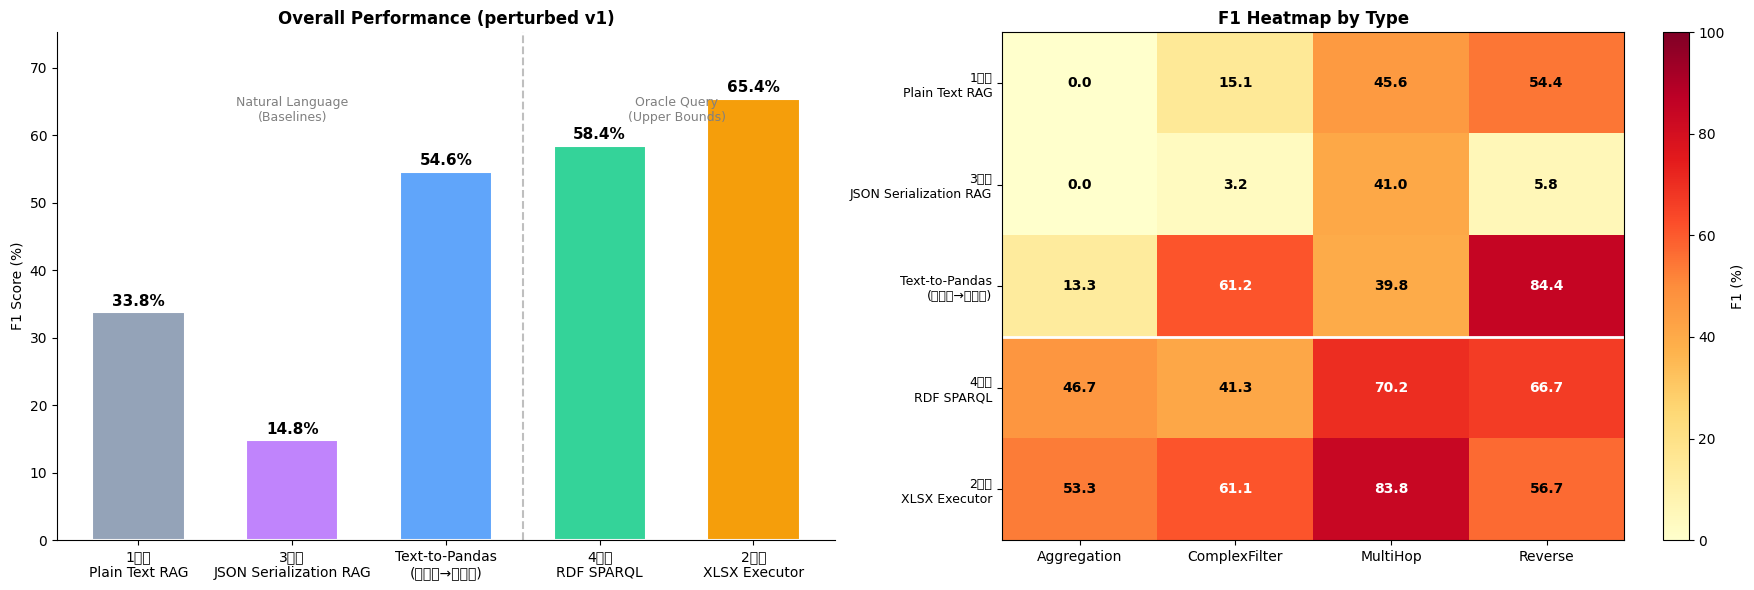

✅ Visualization Saved


In [179]:
# ============================================================
# Cell 17. Visualization
# ============================================================

import matplotlib, matplotlib.pyplot as plt
import numpy as np

# Use default sans-serif font
matplotlib.rcParams["font.family"] = "sans-serif"
matplotlib.rcParams["axes.unicode_minus"] = False

LABELS = {
    M_VEC:  "1단계\nPlain Text RAG",
    M_JSON: "3단계\nJSON Serialization RAG",
    M_T2P:  "Text-to-Pandas\n(자연어→구조화)",
    M_RDF:  "4단계\nRDF SPARQL",
    M_XLSX: "2단계\nXLSX Executor",
}
COLORS = {M_VEC:"#94a3b8", M_JSON:"#c084fc", M_T2P:"#60a5fa", M_RDF:"#34d399", M_XLSX:"#f59e0b"}

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Overall Bar Chart
ax = axes[0]
order = [M_VEC, M_JSON, M_T2P, M_RDF, M_XLSX]
f1s = [overall[overall["method"]==m]["f1"].values[0] for m in order if m in overall["method"].values]
lbs = [LABELS.get(m, m) for m in order if m in overall["method"].values]
clrs = [COLORS.get(m, "gray") for m in order if m in overall["method"].values]
bars = ax.bar(lbs, f1s, color=clrs, edgecolor="white", linewidth=1.5, width=0.6)
for bar, val in zip(bars, f1s):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f"{val:.1f}%", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.axvline(x=2.5, color="gray", linestyle="--", alpha=0.5)
ax.text(1.0, max(f1s)*0.95, "Natural Language\n(Baselines)", ha="center", fontsize=9, color="gray")
ax.text(3.5, max(f1s)*0.95, "Oracle Query\n(Upper Bounds)", ha="center", fontsize=9, color="gray")
ax.set_ylim(0, max(f1s)*1.15)
ax.set_ylabel("F1 Score (%)")
ax.set_title("Overall Performance (perturbed v1)", fontweight="bold")
ax.spines[["top","right"]].set_visible(False)

# Heatmap by Type
ax2 = axes[1]
pivot = type_sum.pivot(index="method", columns="type", values="f1").reindex(order)
im = ax2.imshow(pivot.values, cmap="YlOrRd", aspect="auto", vmin=0, vmax=100)
ax2.set_xticks(range(len(pivot.columns))); ax2.set_xticklabels(pivot.columns, fontsize=10)
ax2.set_yticks(range(len(pivot.index)));   ax2.set_yticklabels([LABELS.get(m,m) for m in pivot.index], fontsize=9)
for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i,j]
        if not np.isnan(val):
            ax2.text(j, i, f"{val:.1f}", ha="center", va="center",
                     fontsize=10, fontweight="bold",
                     color="white" if val>60 else "black")
ax2.axhline(y=2.5, color="white", linewidth=2)
ax2.set_title("F1 Heatmap by Type", fontweight="bold")
plt.colorbar(im, ax=ax2, label="F1 (%)")
plt.tight_layout()
plt.savefig(FIG_DIR / "5method_perturbed_v1_results_en.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Visualization Saved")


In [180]:
# ============================================================
# Cell 18. Diagnostics — Plan 분포, Noise level별 성능, 저성능 케이스
# ============================================================

# (1) Text-to-Pandas Plan operation 분포
plans = []
for x in t2p_df["text_to_pandas_plan"].fillna("{}").astype(str):
    try: plans.append(json.loads(x))
    except: plans.append({})
plan_diag = pd.DataFrame({
    "id": t2p_df["id"],
    "operation": [p.get("operation","parse_error") for p in plans],
    "table":     [p.get("table","parse_error")     for p in plans],
    "status":    t2p_df["text_to_pandas_status"],
})
plan_diag.to_csv(LOG_DIR / "text_to_pandas_plan_diagnostics.csv", index=False, encoding="utf-8-sig")
print("=== Text-to-Pandas Operation 분포 ===")
display(plan_diag["operation"].value_counts())
print("\n=== Status 분포 ===")
display(plan_diag["status"].value_counts())

# (2) Noise level별 4-method 성능 (L1/L2/L3 robustness 분석)
noise_eval = eval_long.merge(
    gold_pert[["id","question_noise_level","noise_type","question_pattern"]],
    on="id", how="left"
)
noise_summary = noise_eval.groupby(["method","question_noise_level"]).agg(
    n=("id","count"), f1=("f1","mean")
).reset_index()
noise_summary["f1"] = (noise_summary["f1"]*100).round(2)
noise_summary.to_csv(RESULT_DIR / "noise_level_summary_5methods_perturbed_v1.csv",
                     index=False, encoding="utf-8-sig")
print("\n=== Noise Level별 F1 (L1/L2/L3 robustness) ===")
display(noise_summary.pivot(index="method", columns="question_noise_level", values="f1"))

# (3) 저성능 케이스 (F1 < 0.5)
for method_name in [M_VEC, M_T2P, M_RDF, M_XLSX]:
    low = eval_long[(eval_long["method"]==method_name) & (eval_long["f1"]<0.5)]
    if len(low)==0: continue
    safe_name = method_name.replace(" ","_").replace(":","").lower()
    if method_name == M_T2P:
        # text_to_pandas_error 대신 text_to_pandas_status 사용
        low = low.merge(t2p_df[["id","text_to_pandas_plan","text_to_pandas_status"]], on="id", how="left")
    low.to_csv(LOG_DIR / f"low_f1_{safe_name}.csv", index=False, encoding="utf-8-sig")
    print(f"\n=== {method_name} 저성능 ({len(low)}건) ===")
    display(low[["id","type","question","pred","f1"]].head(5))

print("\n✅ Diagnostics 저장 완료")

=== Text-to-Pandas Operation 분포 ===


,count
operation,
parse_error,100



=== Status 분포 ===


,count
status,
ok,100



=== Noise Level별 F1 (L1/L2/L3 robustness) ===


...


=== RDF Template SPARQL v3 저성능 (37건) ===


,id,type,question,pred,f1
302,MH03,MultiHop,한국산업은행이 시행하는 사업들의 소관기관과 지원형태를 각각 알려줘.,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)",0.000000
303,MH04,MultiHop,한국에너지공단이 진행하는 사업들은 어떤 분야에 속하나요?,산업 중소기업 및 에너지,0.000000
307,MH08,MultiHop,AI컴퓨팅자원활용기반강화 사업을 수행하는 기관들이 맡고 있는 다른 사업 이름을 최대 3개까지 알려주세요.,,0.000000
313,RV06,Reverse,3년 동안 진행되는 새로 시작하는 사업 중 3개를 알려주세요.,개인정보 안전활용 선도기술 개발(R&D) | 치안데이터활용기술개발 (R&D) | 4대 지역외 AX 대전환 기획,0.333333
317,CF04,ComplexFilter,2026년에 예산이 전년보다 줄어들었고 계속 사업으로 과기정통부 소관인 사업을 최대 3개까지 알려주세요.,,0.000000



=== XLSX Template Executor v4 저성능 (33건) ===


,id,type,question,pred,f1
402,MH03,MultiHop,한국산업은행이 시행하는 사업들의 소관기관과 지원형태를 각각 알려줘.,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)",0.000000
404,MH05,MultiHop,2026년에 정보통신기획평가원이 시행하는 사업들의 예산 총액은 얼마인가요?,1341298백만원,0.000000
407,MH08,MultiHop,AI컴퓨팅자원활용기반강화 사업을 수행하는 기관들이 맡고 있는 다른 사업 이름을 최대 3개까지 알려주세요.,전산운영경비(정보화) | 개인정보 안전활용 선도기술 개발(R&D) | 신뢰기반의 AI 개인정보 보호·활용 기술개발(R&D),0.000000
413,RV06,Reverse,3년 동안 진행되는 새로 시작하는 사업 중 3개를 알려주세요.,개인정보 안전활용 선도기술 개발(R&D) | 치안데이터활용기술개발 (R&D) | 4대 지역외 AX 대전환 기획,0.333333
419,CF06,ComplexFilter,일반회계에 속하고 보조사업 형태로 2026년에 새로 시작하는 사업 중에서 예산이 가장 큰 사업은 무엇인가요?,AI 기반 분산전력망 산업 육성,0.000000



✅ Diagnostics 저장 완료


In [181]:
# ============================================================
# Cell 19. RDF graph 검증 (선택)
# ============================================================
if TTL_PATH.exists():
    try:
        from rdflib import Graph as RDFGraph, RDF as RDF_TYPE
        g_check = RDFGraph()
        g_check.parse(str(TTL_PATH), format="turtle")
        type_counts = Counter(str(o) for s, o in g_check.subject_objects(RDF_TYPE))
        rdf_report = pd.DataFrame([
            {"class_uri": cls, "instance_count": cnt}
            for cls, cnt in sorted(type_counts.items(), key=lambda x: x[1], reverse=True)
        ])
        rdf_report.to_csv(LOG_DIR / "rdf_type_counts.csv", index=False, encoding="utf-8-sig")
        print(f"✅ RDF graph 검증 완료 — {len(g_check):,} triples")
        display(rdf_report.head(20))
    except Exception as e:
        print(f"⚠️ RDF 검증 실패: {e}")
else:
    print("⚠️ TTL 파일 없음 — RDF 검증 생략")

✅ RDF graph 검증 완료 — 11,042 triples


""


In [182]:
# ============================================================
# Cell 20. Manifest JSON 생성 (재현성 메타데이터)
# ============================================================

manifest = {
    "experiment_name": "5method_perturbed_v1",
    "created_at": datetime.now().isoformat(),
    "methods": [M_VEC, M_JSON, M_T2P, M_RDF, M_XLSX],
    "machine_readable_mapping": {
        "1단계_PDF":          "Plain Text Vector RAG",
        "2단계_HWPX_XLSX":    "XLSX Template Executor v4",
        "3단계_CSV_JSON_XML": "JSON Vector RAG (신규)",
        "3단계_alt_query":    "Text-to-Pandas Agent",
        "4단계_RDF":          "RDF Template SPARQL v3",
        "5단계_LOD":          "한계 + 향후과제 (미구현)",
    },
    "design_principles": {
        "no_reuse_of_v3": "기존 3-method v3 결과 재사용 없음",
        "single_evaluator": "45 method 모두 동일 evaluator로 평가",
        "perturbed_fixed": "perturbed 질문은 한 번 생성 후 고정",
        "no_oracle": "acceptable_answers/gold는 평가 단계에서만 사용",
    },
    "files": {
        "perturbed_gold":      str(PERTURBED_GOLD_PATH.relative_to(ROOT)),
        "perturb_quality":     str(PERTURB_CHECK_PATH.relative_to(ROOT)),
        "vector_predictions":  str(VECTOR_PRED_PATH.relative_to(ROOT)),
        "json_rag_predictions": str(JSON_RAG_PRED_PATH.relative_to(ROOT)) if JSON_RAG_PRED_PATH.exists() else "N/A",
        "t2p_predictions":     str(T2P_PRED_PATH.relative_to(ROOT)),
        "rdf_predictions":     str(RDF_PRED_PATH.relative_to(ROOT)),
        "xlsx_predictions":    str(XLSX_PRED_PATH.relative_to(ROOT)),
        "comparison_5m":       str(COMPARISON_4M_PATH.relative_to(ROOT)),
        "eval_long_5m":        str(EVAL_LONG_4M_PATH.relative_to(ROOT)),
        "overall_5m":          str(OVERALL_4M_PATH.relative_to(ROOT)),
        "type_5m":             str(TYPE_4M_PATH.relative_to(ROOT)),
        "bootstrap_5m":        str(BOOT_4M_PATH.relative_to(ROOT)),
        "bootstrap_type_5m":   str(BOOT_TYPE_4M_PATH.relative_to(ROOT)),
    },
    "summary_f1": {row["method"]: row["f1"] for _, row in overall.iterrows()},
}
manifest_path = ROOT / "manifest_5methods_perturbed_v1.json"
manifest_path.write_text(json.dumps(manifest, ensure_ascii=False, indent=2), encoding="utf-8")
print("✅ Manifest 저장:", manifest_path)
print(json.dumps(manifest["summary_f1"], ensure_ascii=False, indent=2))

✅ Manifest 저장: /content/2026_AI_Budget_Projects/manifest_5methods_perturbed_v1.json
{
  "JSON Serialization Vector RAG": 14.83,
  "Plain Text Vector RAG": 33.77,
  "RDF Template SPARQL v3": 58.4,
  "Text-to-Pandas Agent": 54.57,
  "XLSX Template Executor v4": 65.4
}


In [183]:
# ============================================================
# Cell 18. 결과 패키지 ZIP 생성 & 다운로드
# ============================================================

ZIP_PATH = ROOT / f"5method_perturbed_v1_{datetime.now().strftime('%Y%m%d_%H%M')}.zip"

with zipfile.ZipFile(ZIP_PATH, "w", zipfile.ZIP_DEFLATED) as zf:
    for folder in [GOLD_DIR, PRED_DIR, RESULT_DIR, BOOT_DIR, FIG_DIR]:
        for f in sorted(folder.rglob("*")):
            if f.is_file() and ("perturbed_v1" in f.name or f.suffix in [".png"]):
                zf.write(f, f.relative_to(ROOT))

print(f"✅ ZIP: {ZIP_PATH} ({ZIP_PATH.stat().st_size/1024:.1f} KB)")
with zipfile.ZipFile(ZIP_PATH) as zf:
    for n in sorted(zf.namelist()):
        print(f"  {n}")

files.download(str(ZIP_PATH))

✅ ZIP: /content/2026_AI_Budget_Projects/5method_perturbed_v1_20260506_2347.zip (430.2 KB)
  data/goldset/query_logic_fullset_perturbed_v1.csv
  data/predictions/final_comparison_4methods_perturbed_v1.csv
  data/predictions/final_comparison_5methods_perturbed_v1.csv
  data/predictions/json_rag_predictions_perturbed_v1.csv
  data/predictions/rdf_predictions_perturbed_v1.csv
  data/predictions/text_to_pandas_predictions_perturbed_v1.csv
  data/predictions/vector_predictions_perturbed_v1.csv
  data/predictions/xlsx_predictions_perturbed_v1.csv
  figures/4method_perturbed_v1_results.png
  figures/4method_perturbed_v1_results_en.png
  figures/5method_perturbed_v1_results_en.png
  results/bootstrap/paired_bootstrap_4methods_perturbed_v1_percent.csv
  results/bootstrap/paired_bootstrap_5methods_perturbed_v1_percent.csv
  results/bootstrap/paired_bootstrap_by_type_4methods_perturbed_v1_percent.csv
  results/bootstrap/paired_bootstrap_by_type_5methods_perturbed_v1_percent.csv
  results/final/fin

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [185]:
from pathlib import Path
import pandas as pd

ROOT = Path("/content/2026_AI_Budget_Projects")
PRED_DIR = ROOT / "data/predictions"

# 1) patched final comparison 파일 찾기
candidate_paths = [
    PRED_DIR / "final_comparison_5methods_perturbed_v1.csv",
    PRED_DIR / "final_comparison_4methods_perturbed_v1.csv",
]

comp_path = next((p for p in candidate_paths if p.exists()), None)

if comp_path is None:
    raise FileNotFoundError(
        "final_comparison 파일을 찾지 못했습니다. "
        "data/predictions/final_comparison_5methods_perturbed_v1.csv 또는 "
        "final_comparison_4methods_perturbed_v1.csv가 필요합니다."
    )

comp5_patched = pd.read_csv(comp_path)
print("✅ loaded:", comp_path)
print(comp5_patched.shape)
print(comp5_patched.columns.tolist())

# 2) 필수 컬럼 확인
required_cols = ["id", "rdf_pred", "xlsx_pred"]

missing = [c for c in required_cols if c not in comp5_patched.columns]
if missing:
    raise ValueError(f"comparison 파일에 필수 컬럼이 없습니다: {missing}")

# status 컬럼이 없으면 생성
if "rdf_status" not in comp5_patched.columns:
    comp5_patched["rdf_status"] = "ok"

if "xlsx_status" not in comp5_patched.columns:
    comp5_patched["xlsx_status"] = "ok"

# 3) patched 값이 실제로 반영됐는지 확인
check_ids = ["MH03", "MH07", "RV01", "MH33", "MH34"]

display(
    comp5_patched[comp5_patched["id"].isin(check_ids)][
        ["id", "rdf_pred", "xlsx_pred", "rdf_status", "xlsx_status"]
    ]
)

# 4) 개별 prediction 파일을 final comparison 기준으로 동기화
RDF_PRED_PATH = PRED_DIR / "rdf_predictions_perturbed_v1.csv"
XLSX_PRED_PATH = PRED_DIR / "xlsx_predictions_perturbed_v1.csv"

rdf_out = comp5_patched[["id", "rdf_pred", "rdf_status"]].copy()
xlsx_out = comp5_patched[["id", "xlsx_pred", "xlsx_status"]].copy()

rdf_out.to_csv(RDF_PRED_PATH, index=False, encoding="utf-8-sig")
xlsx_out.to_csv(XLSX_PRED_PATH, index=False, encoding="utf-8-sig")

print("✅ RDF prediction synced:", RDF_PRED_PATH)
print("✅ XLSX prediction synced:", XLSX_PRED_PATH)

# 5) bad case 재확인
for name, df, col in [
    ("rdf", rdf_out, "rdf_pred"),
    ("xlsx", xlsx_out, "xlsx_pred"),
]:
    bad = df[df[col].astype(str).str.contains("미지원|조건에 맞는 결과 없음|알 수 없음|필수 컬럼 없음", na=False)]
    print(f"{name} bad:", len(bad))
    if len(bad) > 0:
        display(bad)

✅ loaded: /content/2026_AI_Budget_Projects/data/predictions/final_comparison_5methods_perturbed_v1.csv
(100, 21)
['id', 'type', 'question', 'question_original', 'query_logic', 'gold', 'acceptable_answers', 'answer_limit', 'evaluation_mode', 'question_noise_level', 'noise_type', 'question_pattern', 'vector_pred', 'json_rag_pred', 'text_to_pandas_pred', 'text_to_pandas_plan', 'text_to_pandas_status', 'rdf_pred', 'rdf_status', 'xlsx_pred', 'xlsx_status']


,id,rdf_pred,xlsx_pred,rdf_status,xlsx_status
2,MH03,"(과학기술 정보통신부, 출자) | (금융위원회, 출자)","(과학기술 정보통신부, 출자) | (금융위원회, 출자)",ok_patch,ok_patch
6,MH07,미정 | 해양수산과학기술진흥원 | 해양경찰청,미정 | 해양수산과학기술진흥원 | 해양경찰청,ok_patch,ok
8,RV01,28개,28개,ok_patch,ok
40,MH33,문화예술 | 방송통신 | 정보통신,문화예술 | 방송통신 | 정보통신,ok_patch,ok
41,MH34,정보통신 | 산업혁신지원 | 과학기술 연구지원,정보통신 | 산업혁신지원 | 과학기술 연구지원,ok_patch,ok


✅ RDF prediction synced: /content/2026_AI_Budget_Projects/data/predictions/rdf_predictions_perturbed_v1.csv
✅ XLSX prediction synced: /content/2026_AI_Budget_Projects/data/predictions/xlsx_predictions_perturbed_v1.csv
rdf bad: 0
xlsx bad: 0


In [186]:
# patched comparison 기준 평가 결과가 최신인지 확인
overall_path = "/content/2026_AI_Budget_Projects/results/final/overall_summary_5methods_perturbed_v1.csv"
overall = pd.read_csv(overall_path)
display(overall)

# RDF/XLSX가 2347 결과처럼 반영됐는지 확인
overall[overall["method"].isin(["RDF Template SPARQL v3", "XLSX Template Executor v4"])]

,method,n,precision,recall,f1,f1_ge07
0,JSON Serialization Vector RAG,100,18.0,13.83,14.83,7.0
1,Plain Text Vector RAG,100,43.5,30.67,33.77,23.0
2,RDF Template SPARQL v3,100,59.5,57.67,58.40,45.0
3,Text-to-Pandas Agent,100,58.0,53.17,54.57,47.0
4,XLSX Template Executor v4,100,66.5,64.67,65.40,59.0


,method,n,precision,recall,f1,f1_ge07
2,RDF Template SPARQL v3,100,59.5,57.67,58.4,45.0
4,XLSX Template Executor v4,100,66.5,64.67,65.4,59.0


In [187]:
import zipfile
from pathlib import Path
from datetime import datetime
import pandas as pd

ROOT = Path("/content/2026_AI_Budget_Projects")

required = [
    ROOT / "data/predictions/final_comparison_5methods_perturbed_v1.csv",
    ROOT / "data/predictions/rdf_predictions_perturbed_v1.csv",
    ROOT / "data/predictions/xlsx_predictions_perturbed_v1.csv",
    ROOT / "data/predictions/text_to_pandas_predictions_perturbed_v1.csv",
    ROOT / "results/final/final_eval_long_5methods_perturbed_v1.csv",
    ROOT / "results/final/overall_summary_5methods_perturbed_v1.csv",
    ROOT / "results/final/type_summary_5methods_perturbed_v1.csv",
    ROOT / "results/bootstrap/paired_bootstrap_5methods_perturbed_v1_percent.csv",
    ROOT / "results/bootstrap/paired_bootstrap_by_type_5methods_perturbed_v1_percent.csv",
]

report = pd.DataFrame([
    {
        "file": str(p.relative_to(ROOT)),
        "exists": p.exists(),
        "size_bytes": p.stat().st_size if p.exists() else 0,
        "status": "OK" if p.exists() else "MISSING",
    }
    for p in required
])

report_path = ROOT / "artifact_completeness_report_5methods_perturbed_v1.csv"
report.to_csv(report_path, index=False, encoding="utf-8-sig")
display(report)

if not report["exists"].all():
    raise RuntimeError("필수 결과 파일이 누락되었습니다.")

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
zip_path = Path(f"/content/5method_perturbed_v1_FINAL_{timestamp}.zip")

if zip_path.exists():
    zip_path.unlink()

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file in ROOT.rglob("*"):
        if file.is_file():
            zf.write(file, file.relative_to(ROOT.parent))

print("✅ final zip created:", zip_path)

try:
    from google.colab import files
    files.download(str(zip_path))
except Exception as e:
    print("수동 다운로드 경로:", zip_path)


,file,exists,size_bytes,status
0,data/predictions/final_comparison_5methods_perturbed_v1.csv,True,156020,OK
1,data/predictions/rdf_predictions_perturbed_v1.csv,True,8114,OK
2,data/predictions/xlsx_predictions_perturbed_v1.csv,True,10000,OK
3,data/predictions/text_to_pandas_predictions_perturbed_v1.csv,True,40253,OK
4,results/final/final_eval_long_5methods_perturbed_v1.csv,True,136425,OK
5,results/final/overall_summary_5methods_perturbed_v1.csv,True,289,OK
6,results/final/type_summary_5methods_perturbed_v1.csv,True,894,OK
7,results/bootstrap/paired_bootstrap_5methods_perturbed_v1_percent.csv,True,1172,OK
8,results/bootstrap/paired_bootstrap_by_type_5methods_perturbed_v1_percent.csv,True,2323,OK


✅ final zip created: /content/5method_perturbed_v1_FINAL_20260506_2353.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>